## Since the file paths are different outside of Kaggle, this notebook will replicate the original notebook but with the correct file paths

## Football Data Analysis

In this data analysis I'll try to do some data analysis about past football transfers, and then try my hand at predicting the transfer fees of players based on certain attributes. First, let's take a look at what we're working with.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

# Input data files are in the local ../data directory
import os
for dirname, _, filenames in os.walk('../data'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

../data/ratings.zip
../data/transfers.zip
../data/init.py
../data/processed/transfers_engineered_compact.csv
../data/processed/transfers_engineered.csv


In [2]:
transfers = pd.read_csv('../data/transfers.zip', compression='zip')
transfers.head()

,Name,Position,Age,Team_from,League_from,Team_to,League_to,Season,Market_value,Transfer_fee
0,Luís Figo,Right Winger,27,FC Barcelona,LaLiga,Real Madrid,LaLiga,2000-2001,NaN,60000000
1,Hernán Crespo,Centre-Forward,25,Parma,Serie A,Lazio,Serie A,2000-2001,NaN,56810000
2,Marc Overmars,Left Winger,27,Arsenal,Premier League,FC Barcelona,LaLiga,2000-2001,NaN,40000000
3,Gabriel Batistuta,Centre-Forward,31,Fiorentina,Serie A,AS Roma,Serie A,2000-2001,NaN,36150000
4,Nicolas Anelka,Centre-Forward,21,Real Madrid,LaLiga,Paris SG,Ligue 1,2000-2001,NaN,34500000


In [3]:
print(transfers.dtypes)
print(transfers.shape)

Name                str
Position            str
Age               int64
Team_from           str
League_from         str
Team_to             str
League_to           str
Season              str
Market_value    float64
Transfer_fee      int64
dtype: object
(4700, 10)


Some things to settle before we get into the data analysis: 
1. Season should be an int value with just the year
2. Transfer fees and market values both have a lot of 0s. Will convert them into transfer fees in millions to make things easier.
3. Positions are inconsistent: some people are just titled 'defender', 'midfielder' or 'sweeper' but in fact they play a certain position.
4. Someone has age 0 within the dataset, which would be impossible.

For point 3 and 4, if there are a large group of people with these misleading labels then they will be manually inputted. If the group is small, the rows will just be dropped.

In [4]:
transfers['Season_transferred']=transfers['Season'].str.split('-').str[0]
transfers = transfers.astype({'Season_transferred':'int64'})
transfers = transfers.drop(columns =['Season'])
transfers.head()

,Name,Position,Age,Team_from,League_from,Team_to,League_to,Market_value,Transfer_fee,Season_transferred
0,Luís Figo,Right Winger,27,FC Barcelona,LaLiga,Real Madrid,LaLiga,NaN,60000000,2000
1,Hernán Crespo,Centre-Forward,25,Parma,Serie A,Lazio,Serie A,NaN,56810000,2000
2,Marc Overmars,Left Winger,27,Arsenal,Premier League,FC Barcelona,LaLiga,NaN,40000000,2000
3,Gabriel Batistuta,Centre-Forward,31,Fiorentina,Serie A,AS Roma,Serie A,NaN,36150000,2000
4,Nicolas Anelka,Centre-Forward,21,Real Madrid,LaLiga,Paris SG,Ligue 1,NaN,34500000,2000


In [5]:
print(transfers.Position.unique())
transfers.Position = transfers.Position.replace(to_replace=['Second Striker','Centre-Forward','Sweeper'],value = ['Forward','Forward','Defender'])
print(transfers.Position.unique())

<StringArray>
[      'Right Winger',     'Centre-Forward',        'Left Winger',
        'Centre-Back',   'Central Midfield', 'Attacking Midfield',
 'Defensive Midfield',     'Second Striker',         'Goalkeeper',
         'Right-Back',      'Left Midfield',          'Left-Back',
     'Right Midfield',            'Forward',            'Sweeper',
           'Defender',         'Midfielder']
Length: 17, dtype: str
<StringArray>
[      'Right Winger',            'Forward',        'Left Winger',
        'Centre-Back',   'Central Midfield', 'Attacking Midfield',
 'Defensive Midfield',         'Goalkeeper',         'Right-Back',
      'Left Midfield',          'Left-Back',     'Right Midfield',
           'Defender',         'Midfielder']
Length: 14, dtype: str


In [6]:
transfers.Age.unique()
transfers_weird = transfers.loc[transfers.Age == 0]
print(transfers_weird)

                  Name Position  Age Team_from    League_from  Team_to  \
236  Marzouq Al-Otaibi  Forward    0    Shabab   Saudi Arabia  Ittihad   

         League_to  Market_value  Transfer_fee  Season_transferred  
236   Saudi Arabia           NaN       2000000                2000  


This is the age 0 person. As it's just one person with an age of 0, I'll drop him.

In [7]:
transfers_midfield = transfers.loc[transfers.Position == 'Midfielder']
print(transfers_midfield.head(20))
transfers_defenders = transfers.loc[transfers.Position =='Defender']
print(transfers_defenders.head(20))

             Name    Position  Age Team_from     League_from Team_to  \
705  Tony Dinning  Midfielder   27    Wolves  First Division   Wigan   

                       League_to  Market_value  Transfer_fee  \
705  Second Division (bis 03/04)           NaN       1130000   

     Season_transferred  
705                2002  
                Name  Position  Age      Team_from     League_from  \
471    Thomas Hengen  Defender   26  VfL Wolfsburg    1.Bundesliga   
652  Sergio Hellings  Defender   17       Ajax U19  U19 Eredivisie   

            Team_to     League_to  Market_value  Transfer_fee  \
471  1.FC K'lautern  1.Bundesliga           NaN       2250000   
652  Anderlecht U19       Belgium           NaN       2000000   

     Season_transferred  
471                2001  
652                2002  


There are only 3 so let's drop all of them to make it easier.

In [8]:
transfers_cleaned= transfers[~((transfers.Position=='Midfielder')|(transfers.Position=='Defender')|(transfers.Age ==0))]
transfers_cleaned['Transfer_fee_in_mln']=transfers_cleaned['Transfer_fee']/1000000
transfers_cleaned['Market_value_in_mln']=transfers_cleaned['Market_value']/1000000
transfers_cleaned = transfers_cleaned.drop(labels = ['Transfer_fee','Market_value'],axis = 1)
pd.to_datetime(transfers_cleaned['Season_transferred'],format ='%Y')
transfers_cleaned.head()


,Name,Position,Age,Team_from,League_from,Team_to,League_to,Season_transferred,Transfer_fee_in_mln,Market_value_in_mln
0,Luís Figo,Right Winger,27,FC Barcelona,LaLiga,Real Madrid,LaLiga,2000,60.00,NaN
1,Hernán Crespo,Forward,25,Parma,Serie A,Lazio,Serie A,2000,56.81,NaN
2,Marc Overmars,Left Winger,27,Arsenal,Premier League,FC Barcelona,LaLiga,2000,40.00,NaN
3,Gabriel Batistuta,Forward,31,Fiorentina,Serie A,AS Roma,Serie A,2000,36.15,NaN
4,Nicolas Anelka,Forward,21,Real Madrid,LaLiga,Paris SG,Ligue 1,2000,34.50,NaN


Let's plot out a distribution of transfer fee by season.

/Users/gkb/responsibleds-audit-2026/.venv/lib/python3.11/site-packages/seaborn/utils.py:105: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scout = method(scout_x, scout_y, **kws)
/Users/gkb/responsibleds-audit-2026/.venv/lib/python3.11/site-packages/seaborn/categorical.py:511: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(sub_data["x"], sub_data["y"], color=color, **plot_kws)


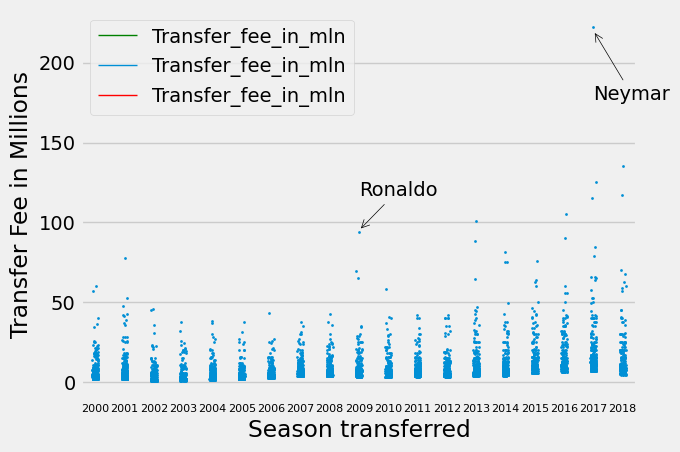

In [9]:
import matplotlib.style as style
style.use('fivethirtyeight')
fig, ax = plt.subplots()
transfers_cleaned.groupby('Season_transferred')['Transfer_fee_in_mln'].quantile(.75).plot(linewidth = 1.0,color = 'g')
transfers_cleaned.groupby('Season_transferred')['Transfer_fee_in_mln'].quantile(.50).plot(linewidth = 1.0)
transfers_cleaned.groupby('Season_transferred')['Transfer_fee_in_mln'].quantile(.90).plot(linewidth = 1.0, color = 'r')
sns.stripplot(x = 'Season_transferred',y='Transfer_fee_in_mln',\
              cmap = 'coolwarm',data= transfers_cleaned,size = 2)
plt.xlabel('Season transferred')
plt.ylabel('Transfer Fee in Millions')
plt.xticks(fontsize = 8)
ax.annotate(text = 'Ronaldo',xy = (9,95),xycoords = 'data',\
            xytext = (0,25),textcoords = 'offset points', arrowprops = dict(arrowstyle ='->', color = 'black'))
ax.annotate(text ='Neymar', xy = (17,220),xycoords = 'data',\
            xytext = (0,-50),textcoords = 'offset points',arrowprops = dict(arrowstyle = '->',color = 'black'))
plt.show()

# observe how transfer fees evolve over time with summary statistics

,Season_transferred,mean_transfer_fee,median_transfer_fee
0,2000,7.534008,4.500
1,2001,8.332651,5.300
2,2002,4.723326,2.655
3,2003,4.580620,2.500
4,2004,5.621734,3.500
5,2005,5.441579,3.600
6,2006,6.196145,4.500
7,2007,8.656210,6.800
8,2008,8.494880,6.350
9,2009,8.758112,5.700


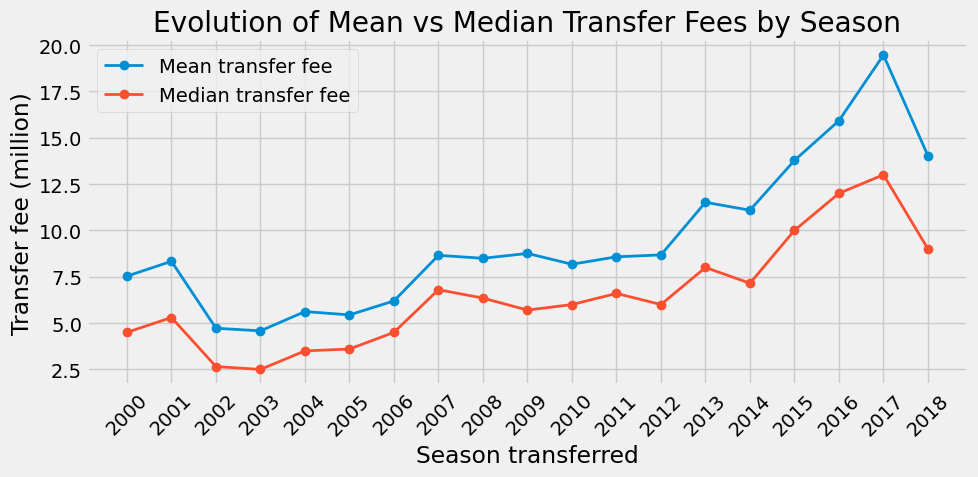

In [10]:
season_fee_stats = (
    transfers_cleaned
    .groupby('Season_transferred')['Transfer_fee_in_mln']
    .agg(mean_transfer_fee='mean', median_transfer_fee='median')
    .reset_index()
)

display(season_fee_stats)

fig14, ax14 = plt.subplots(figsize=(10, 5))
ax14.plot(
    season_fee_stats['Season_transferred'],
    season_fee_stats['mean_transfer_fee'],
    marker='o',
    linewidth=2,
    label='Mean transfer fee'
)
ax14.plot(
    season_fee_stats['Season_transferred'],
    season_fee_stats['median_transfer_fee'],
    marker='o',
    linewidth=2,
    label='Median transfer fee'
)

ax14.set_xlabel('Season transferred')
ax14.set_ylabel('Transfer fee (million)')
ax14.set_title('Evolution of Mean vs Median Transfer Fees by Season')
ax14.legend()
ax14.set_xticks(season_fee_stats['Season_transferred'].astype(int).tolist())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/var/folders/kx/58cjbwzx5jjgn5w_sjz3qk0w0000gn/T/ipykernel_40764/543297698.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


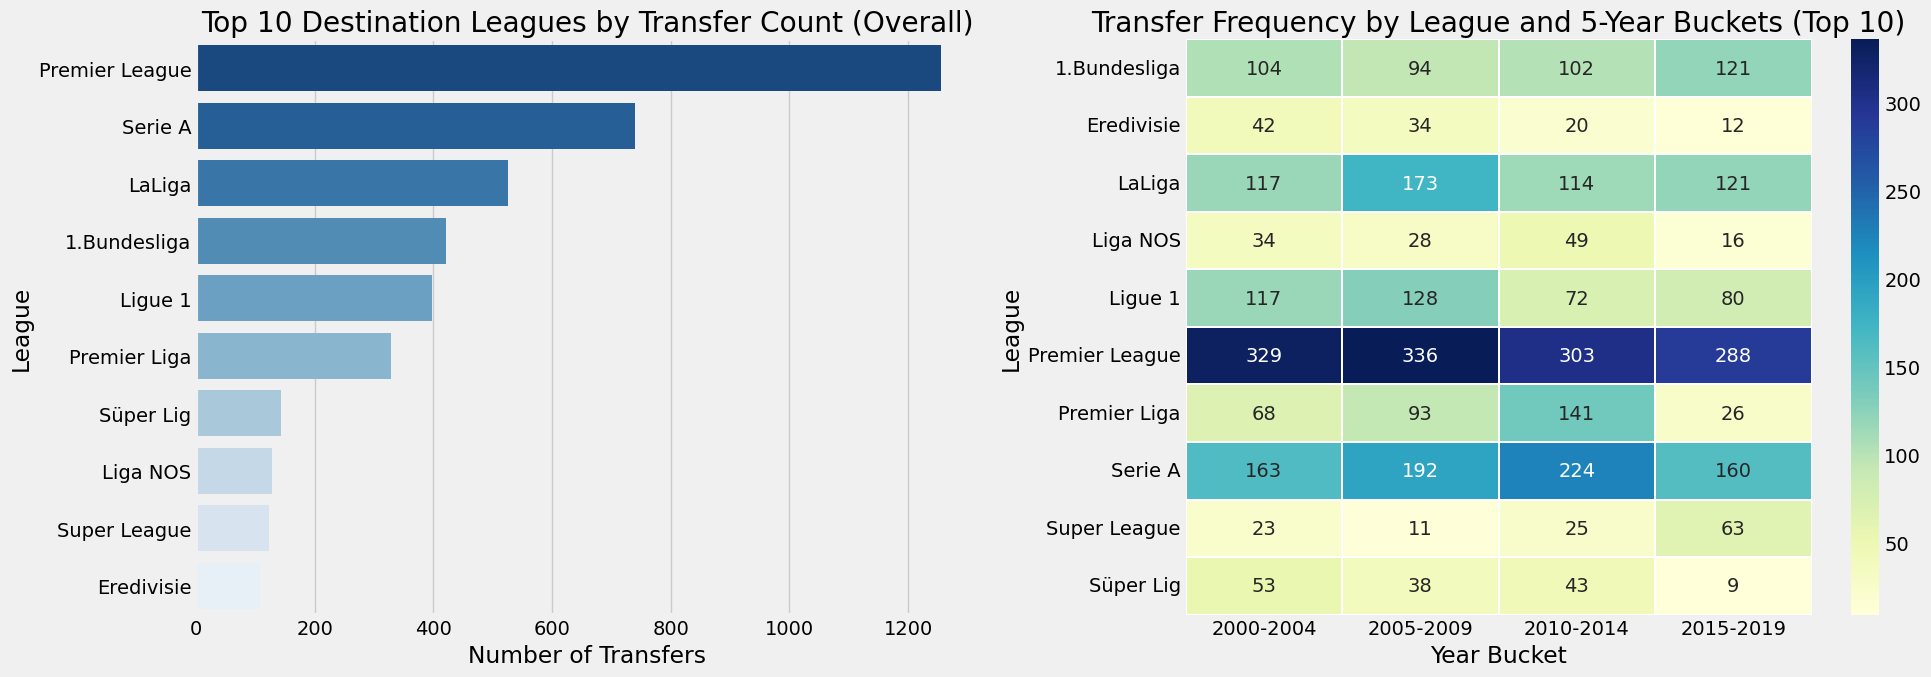

In [11]:
# Frequency of transfers to destination leagues: overall + 5-year buckets
top_n = 10

overall_league_counts = transfers_cleaned['League_to'].value_counts()
top_leagues = overall_league_counts.head(top_n).index

tmp = transfers_cleaned.copy()
tmp['bucket_start'] = (tmp['Season_transferred'] // 5) * 5
tmp['year_bucket'] = tmp['bucket_start'].astype(str) + '-' + (tmp['bucket_start'] + 4).astype(str)

bucket_order = (
    tmp[['bucket_start', 'year_bucket']]
    .drop_duplicates()
    .sort_values('bucket_start')['year_bucket']
    .tolist()
)

bucket_league_counts = (
    tmp[tmp['League_to'].isin(top_leagues)]
    .groupby(['year_bucket', 'League_to'])
    .size()
    .unstack(fill_value=0)
    .reindex(bucket_order, fill_value=0)
)

fig16, axes16 = plt.subplots(1, 2, figsize=(20, 7))

# Overall frequency
sns.barplot(
    x=overall_league_counts.head(top_n).values,
    y=overall_league_counts.head(top_n).index,
    ax=axes16[0],
    palette='Blues_r'
)
axes16[0].set_title(f'Top {top_n} Destination Leagues by Transfer Count (Overall)')
axes16[0].set_xlabel('Number of Transfers')
axes16[0].set_ylabel('League')

# Frequency by 5-year buckets
sns.heatmap(
    bucket_league_counts.T,
    cmap='YlGnBu',
    annot=True,
    fmt='d',
    linewidths=0.3,
    ax=axes16[1]
)
axes16[1].set_title(f'Transfer Frequency by League and 5-Year Buckets (Top {top_n})')
axes16[1].set_xlabel('Year Bucket')
axes16[1].set_ylabel('League')

plt.tight_layout()
plt.show()

/var/folders/kx/58cjbwzx5jjgn5w_sjz3qk0w0000gn/T/ipykernel_40764/3072305190.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


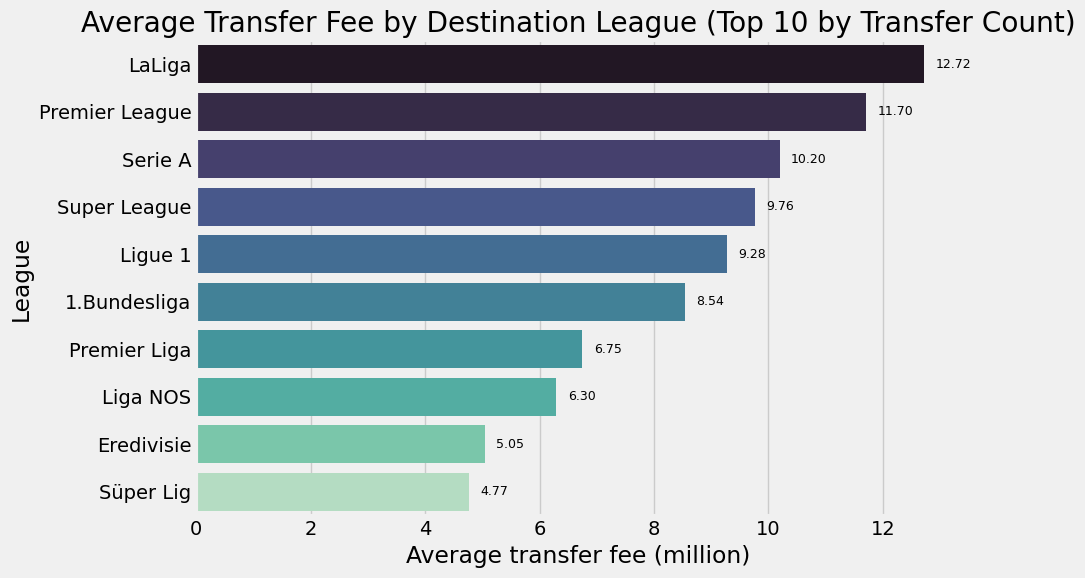

In [12]:
# Average transfer fees to selected destination leagues (top 10 by transfer volume)
selected_leagues = overall_league_counts.head(10).index

avg_fee_by_league = (
    transfers_cleaned[transfers_cleaned['League_to'].isin(selected_leagues)]
    .groupby('League_to', as_index=False)['Transfer_fee_in_mln']
    .mean()
    .sort_values('Transfer_fee_in_mln', ascending=False)
)

fig17, ax17 = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=avg_fee_by_league,
    x='Transfer_fee_in_mln',
    y='League_to',
    palette='mako',
    ax=ax17
)

ax17.set_title('Average Transfer Fee by Destination League (Top 10 by Transfer Count)')
ax17.set_xlabel('Average transfer fee (million)')
ax17.set_ylabel('League')

for i, v in enumerate(avg_fee_by_league['Transfer_fee_in_mln']):
    ax17.text(v + 0.2, i, f'{v:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

League_to,1.Bundesliga,Eredivisie,LaLiga,Liga NOS,Ligue 1,Premier League,Premier Liga,Serie A,Super League,Süper Lig
year_bucket,,,,,,,,,,
2000-2004,4.46,3.73,9.65,3.58,5.42,6.75,3.12,11.47,3.21,3.06
2005-2009,6.58,5.23,10.50,5.53,6.06,8.89,5.61,7.75,4.98,5.17
2010-2014,9.20,5.31,13.54,7.11,12.39,12.39,8.85,7.89,6.38,5.99
2015-2019,13.02,8.68,18.12,10.90,17.26,19.91,8.93,15.06,14.32,7.32


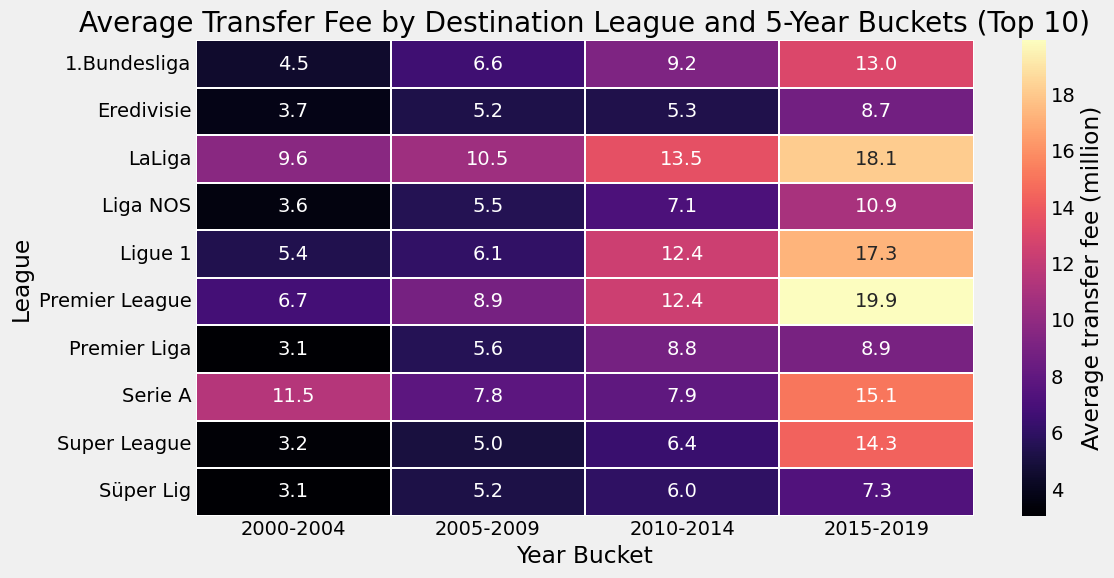

In [13]:
# Average transfer fee by destination league and 5-year buckets
top_n_avg = 10
selected_leagues_avg = overall_league_counts.head(top_n_avg).index

avg_fee_by_bucket_league = (
    tmp[tmp['League_to'].isin(selected_leagues_avg)]
    .groupby(['year_bucket', 'League_to'])['Transfer_fee_in_mln']
    .mean()
    .unstack()
    .reindex(bucket_order)
)

display(avg_fee_by_bucket_league.round(2))

fig18, ax18 = plt.subplots(figsize=(12, 6))
sns.heatmap(
    avg_fee_by_bucket_league.T,
    cmap='magma',
    annot=True,
    fmt='.1f',
    linewidths=0.3,
    cbar_kws={'label': 'Average transfer fee (million)'},
    ax=ax18
)
ax18.set_title(f'Average Transfer Fee by Destination League and 5-Year Buckets (Top {top_n_avg})')
ax18.set_xlabel('Year Bucket')
ax18.set_ylabel('League')
plt.tight_layout()
plt.show()

,League_from,Transfer_fee_in_mln
3,LaLiga,13.238900
4,Liga NOS,12.537528
6,Premier League,11.921891
8,Serie A,11.767409
0,1.Bundesliga,11.593598
5,Ligue 1,10.273107
7,Premier Liga,9.912249
9,Série A,8.596030
2,Eredivisie,8.205684
1,Championship,7.874416


League_from,1.Bundesliga,Championship,Eredivisie,LaLiga,Liga NOS,Ligue 1,Premier League,Premier Liga,Serie A,Série A
year_bucket,,,,,,,,,,
2000-2004,5.20,4.44,5.27,10.78,6.42,6.83,6.95,4.85,13.04,3.20
2005-2009,7.49,6.21,7.58,9.14,9.81,7.67,9.18,8.03,8.52,6.80
2010-2014,9.90,7.00,8.19,12.68,15.09,8.85,13.48,9.39,9.86,9.36
2015-2019,19.03,11.32,14.97,20.87,17.19,18.59,19.17,18.90,16.47,11.45


/var/folders/kx/58cjbwzx5jjgn5w_sjz3qk0w0000gn/T/ipykernel_40764/2666782678.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


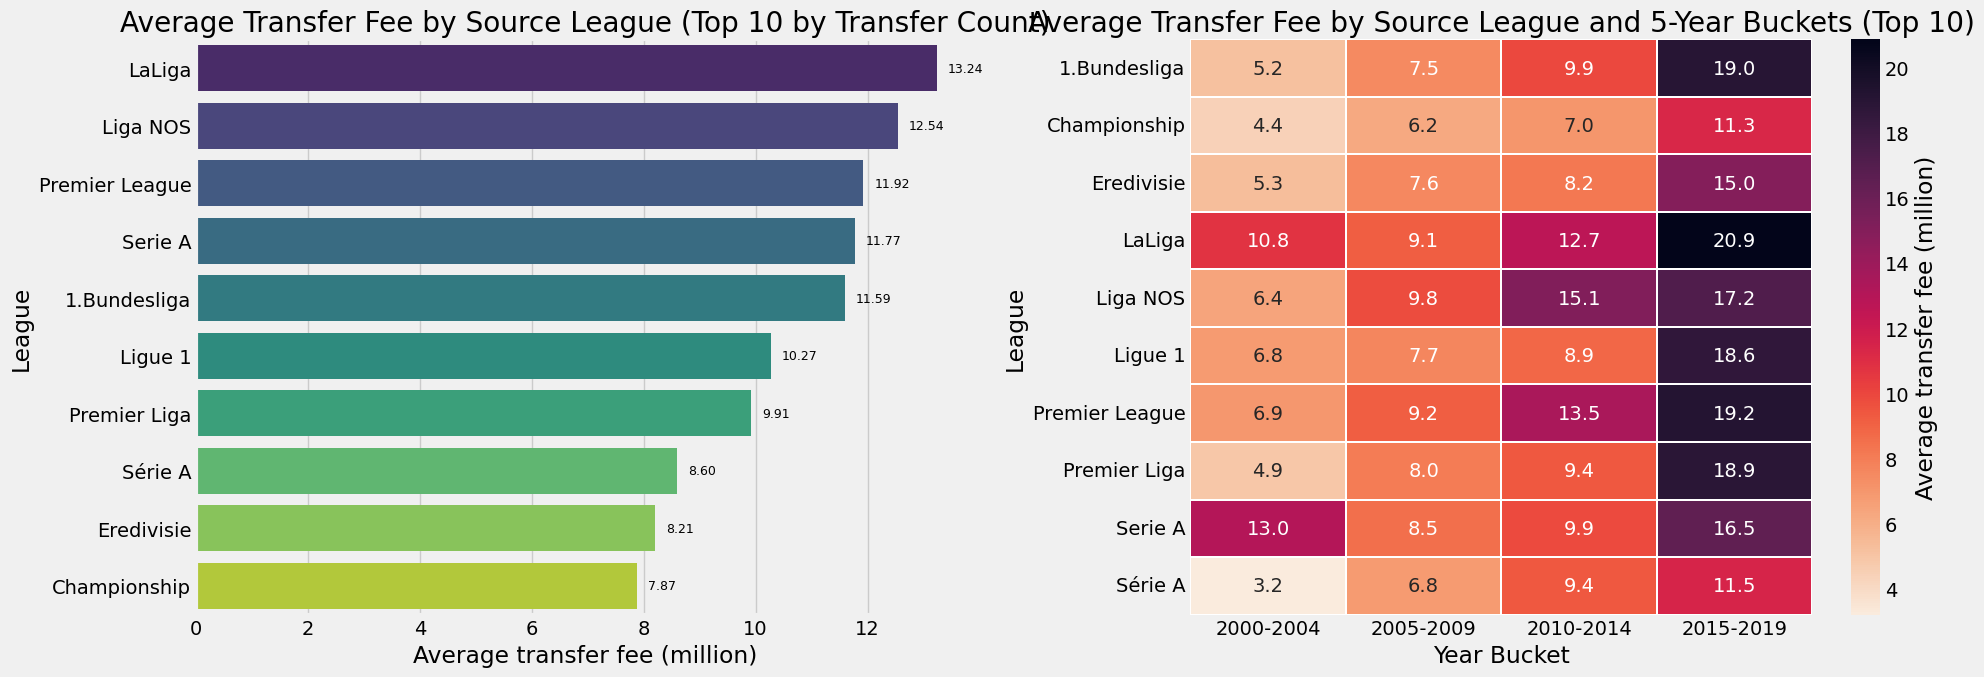

In [14]:
# Average transfer fee by source league (League_from): aggregate + 5-year buckets
top_n_from = 10

from_league_counts = transfers_cleaned['League_from'].value_counts()
selected_from_leagues = from_league_counts.head(top_n_from).index

avg_fee_by_league_from = (
    transfers_cleaned[transfers_cleaned['League_from'].isin(selected_from_leagues)]
    .groupby('League_from', as_index=False)['Transfer_fee_in_mln']
    .mean()
    .sort_values('Transfer_fee_in_mln', ascending=False)
)

avg_fee_by_bucket_from_league = (
    tmp[tmp['League_from'].isin(selected_from_leagues)]
    .groupby(['year_bucket', 'League_from'])['Transfer_fee_in_mln']
    .mean()
    .unstack()
    .reindex(bucket_order)
)

display(avg_fee_by_league_from)
display(avg_fee_by_bucket_from_league.round(2))

fig19, axes19 = plt.subplots(1, 2, figsize=(20, 7))

# Aggregate view
sns.barplot(
    data=avg_fee_by_league_from,
    x='Transfer_fee_in_mln',
    y='League_from',
    palette='viridis',
    ax=axes19[0]
)
axes19[0].set_title(f'Average Transfer Fee by Source League (Top {top_n_from} by Transfer Count)')
axes19[0].set_xlabel('Average transfer fee (million)')
axes19[0].set_ylabel('League')

for i, v in enumerate(avg_fee_by_league_from['Transfer_fee_in_mln']):
    axes19[0].text(v + 0.2, i, f'{v:.2f}', va='center', fontsize=9)

# 5-year bucket view
sns.heatmap(
    avg_fee_by_bucket_from_league.T,
    cmap='rocket_r',
    annot=True,
    fmt='.1f',
    linewidths=0.3,
    cbar_kws={'label': 'Average transfer fee (million)'},
    ax=axes19[1]
)
axes19[1].set_title(f'Average Transfer Fee by Source League and 5-Year Buckets (Top {top_n_from})')
axes19[1].set_xlabel('Year Bucket')
axes19[1].set_ylabel('League')

plt.tight_layout()
plt.show()

In [15]:
transfers_cleaned.columns

Index(['Name', 'Position', 'Age', 'Team_from', 'League_from', 'Team_to',
       'League_to', 'Season_transferred', 'Transfer_fee_in_mln',
       'Market_value_in_mln'],
      dtype='str')

From this first graph, a few conclusions can be drawn:

**1. Transfer fees have been steadily rising with the years.**

Not only have the best players' transfer fees risen as shown by the red line representing the 90th percentile of player transfers, the 75th and 50th percentile lines (green and blue lines respectively) have also shown a steady shift upwards from 2000 to 2018. 

**2. The price of the best players have increased at a higher rate than good, not great players.**

Visually, the number of outliers have risen together with the transfer fees as time progressed. For an outlier-to-outlier comparison, Ronaldo cost 90 million in 2009, while Neymar cost upwards of 200 million in 2017. The 90th percentile line also shows greater deviation from the 75th and 50th percentile lines as time passed.

**3. 2017 was a crazy year.**

The 90th, 75th and 50th percentiles show a large rise from 2016 to 2017. This is due to the transfer of Neymar from Barcelona to PSG, Ousmane Dembele from Dortmund to Barcelona and many other expensive transfers. As we all know though, the prices of all players increased exponentially after that (Mbappe, Coutinho and Ronaldo as examples in 2018), greatly increasing the number of transfers above 100 million.

Text(0, 0.5, 'Transfer Fee in Millions')

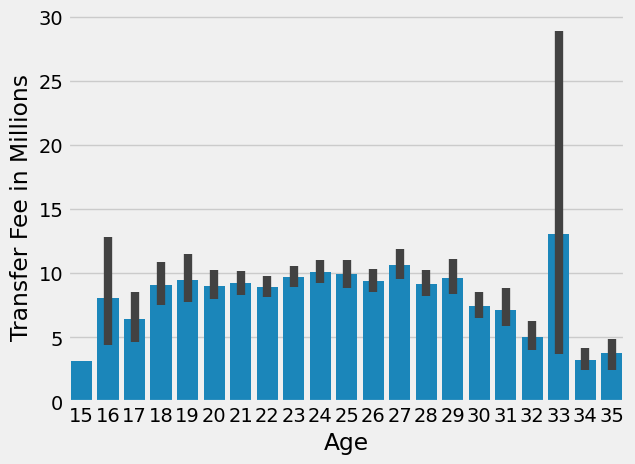

In [16]:
fig2, ax2 = plt.subplots()
sns.barplot(x='Age',y='Transfer_fee_in_mln',data = transfers_cleaned)
plt.xlabel('Age')
plt.ylabel('Transfer Fee in Millions')


From this graph, a few conclusions can be drawn:

**1. Player transfer fees increase as age increases up till 27 years old, and then gradually decrease.**

The graph shows a general upward trend from 15 years to 27 years. However, the graph already begins levelling off at about 24 years old, but a drastic decrease is observed the moment players age over 30.

**2. Remarkably, the variance of player transfer fees are generally independent of age.**

This is a finding that was rather unexpected as one would expect the variation of transfer fees to decrease as players become older, as assessments of a players' ability relative to their age group. However, this was not observed as the confidence interval bars (the black bars) were observed to be roughly the same length across different ages.

**3. Ronaldo has an incredible effect on statistics.**

He is the only reason why the age bar 33 is an anomaly.

In [17]:
transfers_33 = transfers_cleaned[transfers_cleaned['Age']==33]
print(transfers_33.Transfer_fee_in_mln.max())
print(transfers_33.Transfer_fee_in_mln.min())
transfers_15 = transfers_cleaned[transfers_cleaned['Age']==15]
print(transfers_15.head())

117.0
1.0
             Name          Position  Age       Team_from League_from  \
1370  Fran Mérida  Central Midfield   15  Barcelona Yth.       Spain   

          Team_to League_to  Season_transferred  Transfer_fee_in_mln  \
1370  Arsenal U18   England                2005                  3.2   

      Market_value_in_mln  
1370                  NaN  


In [18]:
#fig3, ax3 = plt.subplots()
#sns.stripplot(x='Position',y='Transfer_fee_in_mln',data = transfers_cleaned)
#transfers_cleaned.groupby('Position')['Transfer_fee_in_mln'].quantile(.75).plot(linewidth = 1.0,color = 'g')
#transfers_cleaned.groupby('Position')['Transfer_fee_in_mln'].quantile(.50).plot(linewidth = 1.0)
#transfers_cleaned.groupby('Position')['Transfer_fee_in_mln'].quantile(.90).plot(linewidth = 1.0, color = 'r')
#plt.xlabel('Position')
#plt.xticks(rotation = 60)
#plt.ylabel('Transfer Fee in Millions')

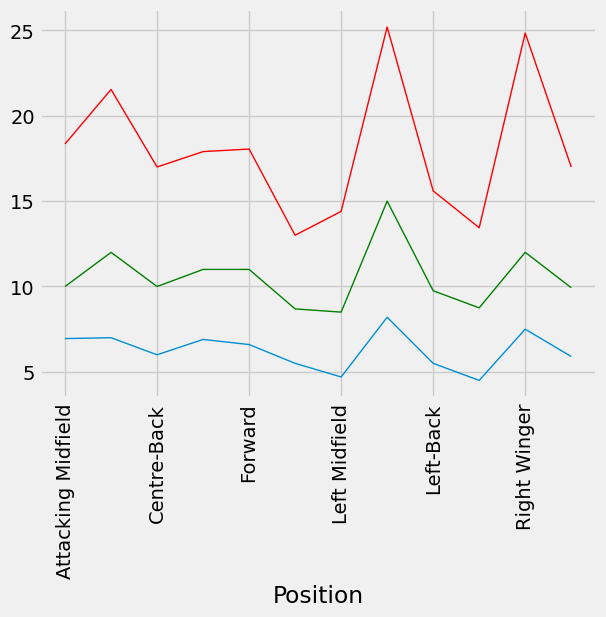

In [19]:
transfers_cleaned.groupby('Position')['Transfer_fee_in_mln'].quantile(.75).plot(linewidth = 1.0,color = 'g')
transfers_cleaned.groupby('Position')['Transfer_fee_in_mln'].quantile(.50).plot(linewidth = 1.0)
transfers_cleaned.groupby('Position')['Transfer_fee_in_mln'].quantile(.90).plot(linewidth = 1.0, color = 'r')
plt.xticks(rotation = 90)
plt.show()

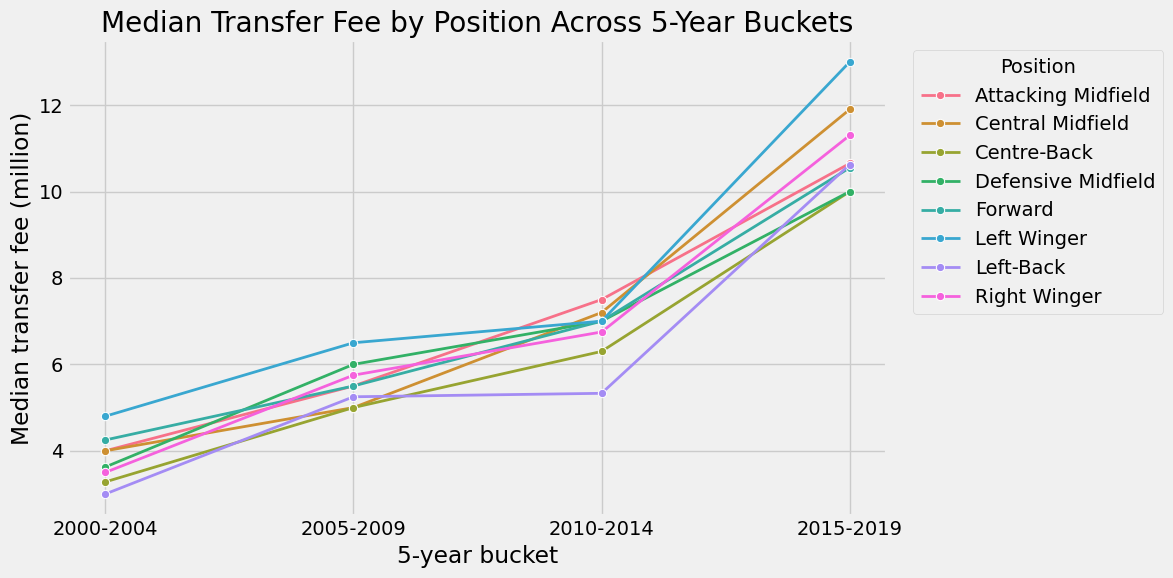

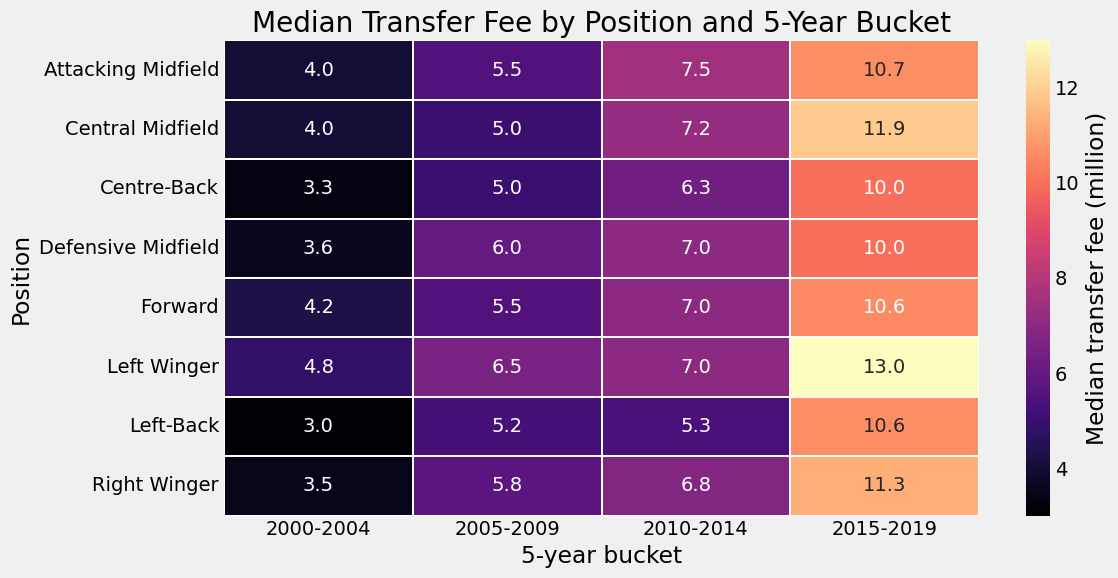

In [20]:
# Transfer fee evolution by position across 5-year buckets
top_positions = tmp['Position'].value_counts().head(8).index

position_bucket_stats = (
    tmp[tmp['Position'].isin(top_positions)]
    .groupby(['year_bucket', 'Position'])['Transfer_fee_in_mln']
    .median()
    .reset_index()
)

position_bucket_stats['year_bucket'] = pd.Categorical(
    position_bucket_stats['year_bucket'],
    categories=bucket_order,
    ordered=True
)
position_bucket_stats = position_bucket_stats.sort_values('year_bucket')

fig_pos, ax_pos = plt.subplots(figsize=(12, 6))
sns.lineplot(
    data=position_bucket_stats,
    x='year_bucket',
    y='Transfer_fee_in_mln',
    hue='Position',
    marker='o',
    linewidth=2,
    ax=ax_pos
)

ax_pos.set_title('Median Transfer Fee by Position Across 5-Year Buckets')
ax_pos.set_xlabel('5-year bucket')
ax_pos.set_ylabel('Median transfer fee (million)')
ax_pos.legend(title='Position', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

position_bucket_heatmap = (
    position_bucket_stats
    .pivot(index='Position', columns='year_bucket', values='Transfer_fee_in_mln')
    .reindex(columns=bucket_order)
    .sort_index()
    .round(2)
)

fig_pos_hm, ax_pos_hm = plt.subplots(figsize=(12, 6))
sns.heatmap(
    position_bucket_heatmap,
    cmap='magma',
    annot=True,
    fmt='.1f',
    linewidths=0.3,
    cbar_kws={'label': 'Median transfer fee (million)'},
    ax=ax_pos_hm
)

ax_pos_hm.set_title('Median Transfer Fee by Position and 5-Year Bucket')
ax_pos_hm.set_xlabel('5-year bucket')
ax_pos_hm.set_ylabel('Position')
plt.tight_layout()
plt.show()

What is the correlation between market value and transfer fees?

Text(0.5, 44.000000000000014, 'Market Value in Millions')

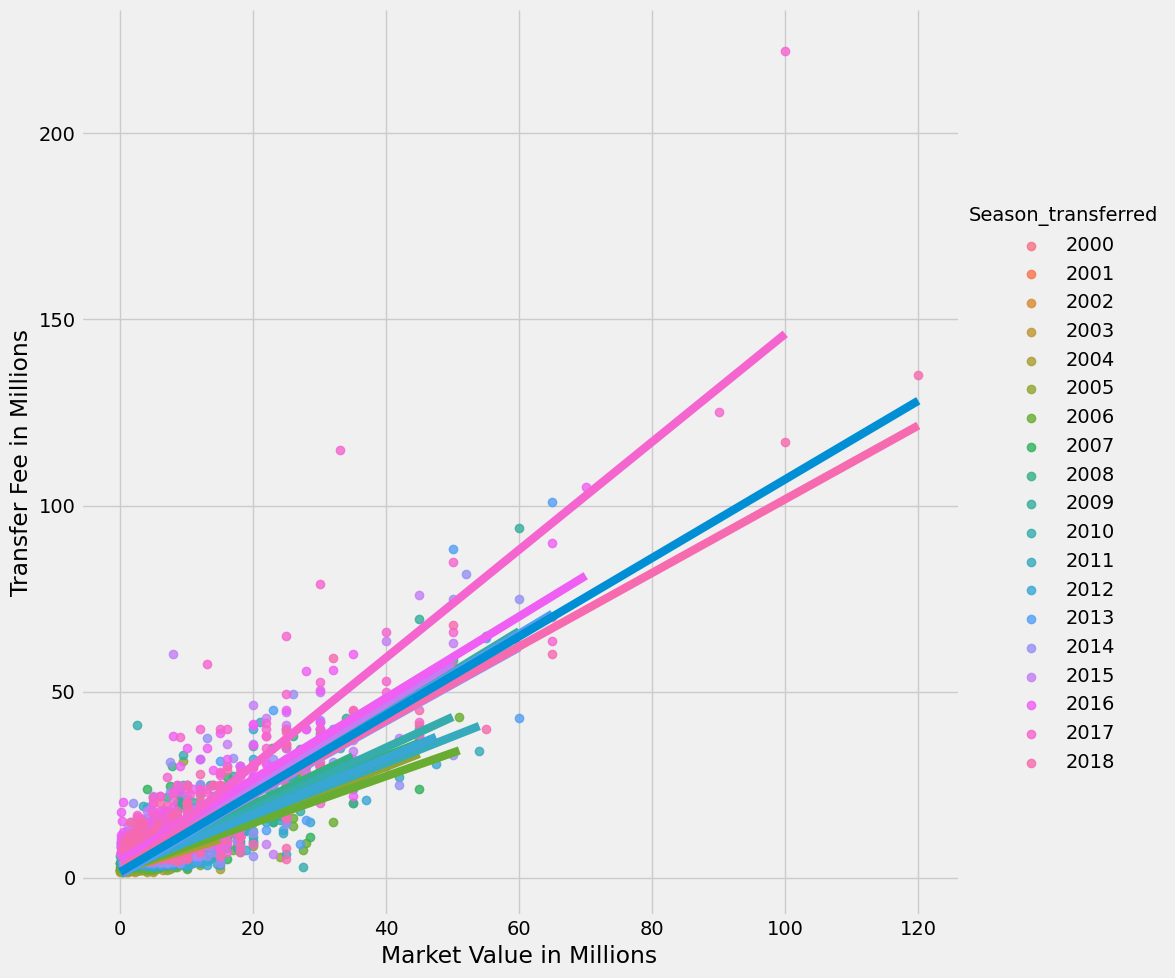

In [21]:
sns.lmplot(x='Market_value_in_mln',y='Transfer_fee_in_mln',data=transfers_cleaned, ci = None, hue = 'Season_transferred',height = 10)
sns.regplot(x='Market_value_in_mln',y='Transfer_fee_in_mln',data=transfers_cleaned, ci = None, scatter = None, label ='Aggregated transfers')
plt.ylabel('Transfer Fee in Millions')
plt.xlabel('Market Value in Millions')

The blue line is the aggregated best fit line of transfer fees to market values. A few conclusions can be drawn here:

**1. People are more prone to overpaying now as compared to last time.**

The ratio of a player's transfer fee to their actual market value is given by the gradient of the graph. By inspection, the most recent years, namely 2015-2018, have had both the highest gradient and the biggest impact on the aggregated best fit line as there are more lines below the aggregated best fit line than there are above the best fit line.

Thus it should be noted that overpayment is a relatively recent phenomenon and it has become more pronounced in recent years.

**HOWEVER**, it is very important to caveat that market values for many players were listed as null values in the DataFrame we were working with, especially for earlier years, and this may lead to inaccuracies within the data. While this does not change the fact that teams are overpaying for players, this may mask the extent of overpayment in past years.

**2. Inflation is a big thing in football transfers, and even more so recently.**

Market value and transfer fees are both a representation of larger economic forces (e.g. inflation) at play. While it is impossible to determine whether Neymar in 2017 was objectively a better player than Ronaldo in 2009, it cannot be denied that inflation has taken place in that span as the large majority of outlying points are from recent years (2015-2018). 

**3. That being said, market value is subjective.**

It is important to note that these figures are not representative of a player's actual value, and as different clubs will value different players differently, there is no such thing as an inherently quantifiable market value for a player. So it's definitely possible and likely that Juve didn't overpay for an ageing Ronaldo, or PSG for Neymar - after all, the only valuation that actually matters is that of the team buying the player and selling the player.

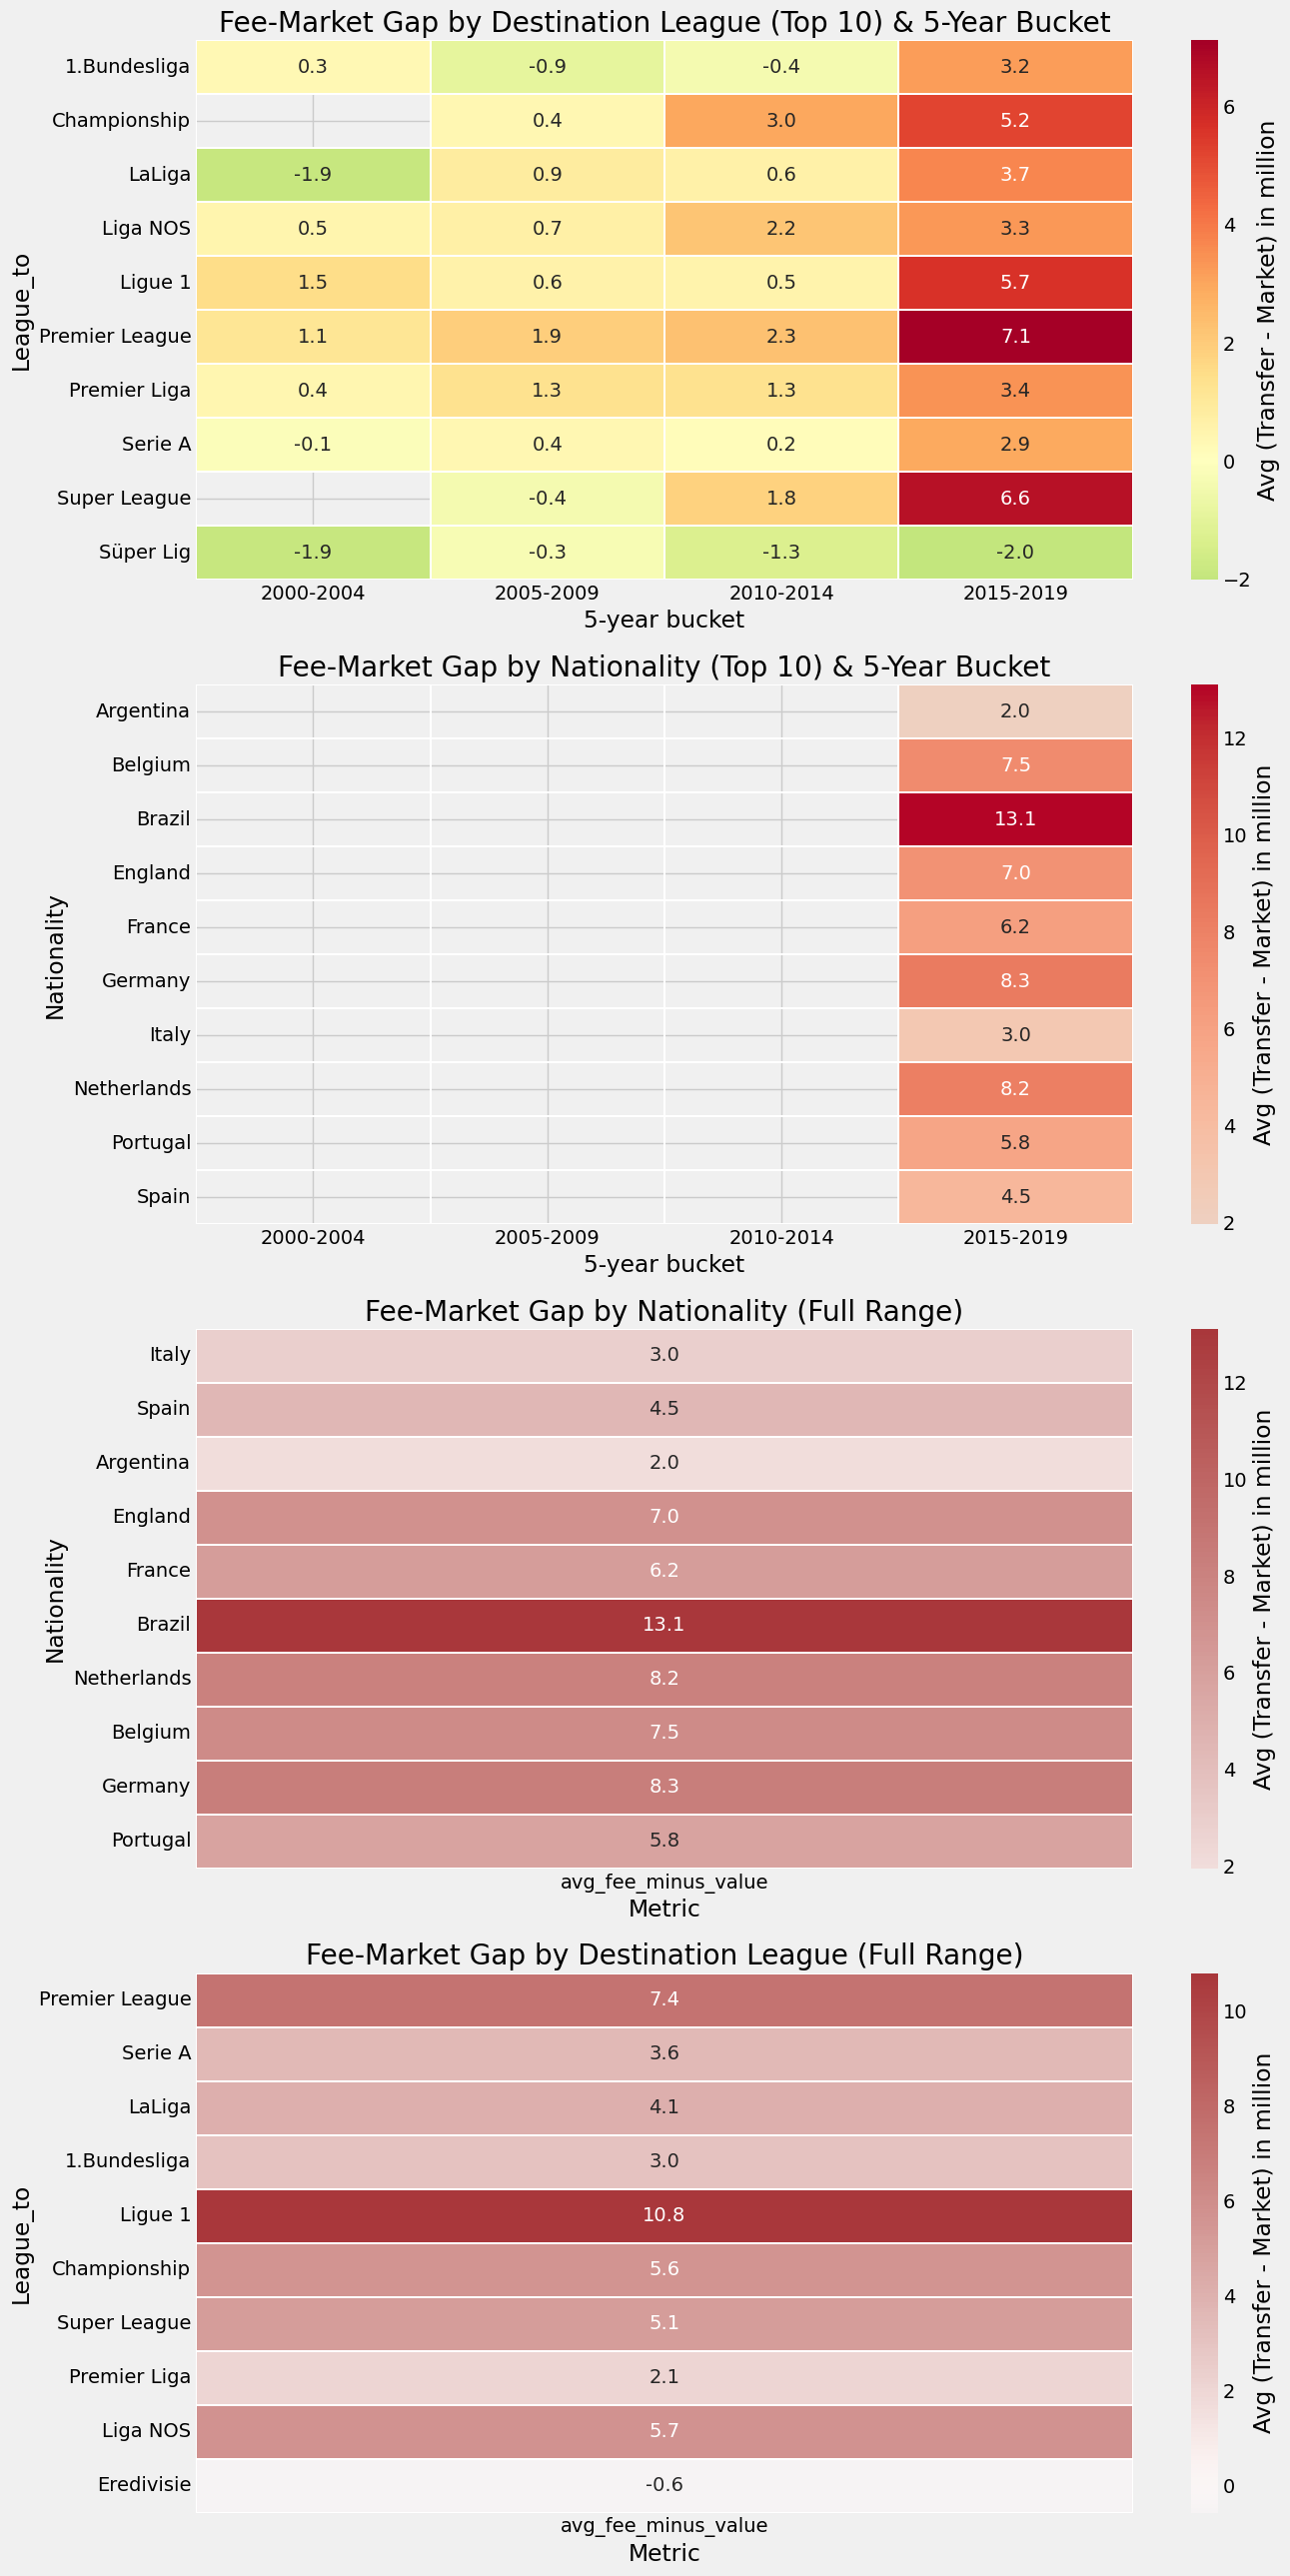

In [22]:
# Feature engineering: difference between transfer fee and market value
gap_df = transfers_cleaned.dropna(subset=['Market_value_in_mln', 'Transfer_fee_in_mln']).copy()
gap_df['fee_minus_value'] = gap_df['Transfer_fee_in_mln'] - gap_df['Market_value_in_mln']

# 5-year buckets
gap_df['bucket_start'] = (gap_df['Season_transferred'] // 5) * 5
gap_df['year_bucket'] = gap_df['bucket_start'].astype(int).astype(str) + '-' + (gap_df['bucket_start'] + 4).astype(int).astype(str)
bucket_order = (
    gap_df[['bucket_start', 'year_bucket']]
    .drop_duplicates()
    .sort_values('bucket_start')['year_bucket']
    .tolist()
)

# ---------------------------
# 1) Heatmap by destination league (top 10)
# ---------------------------
top10_leagues = gap_df['League_to'].value_counts().head(10).index

gap_league_hm = (
    gap_df[gap_df['League_to'].isin(top10_leagues)]
    .groupby(['year_bucket', 'League_to'])['fee_minus_value']
    .mean()
    .unstack(fill_value=np.nan)
    .reindex(bucket_order)
)

# ---------------------------
# 2) Build nationality-enriched transfer set (2015-2018) using FIFA files
# ---------------------------
import zipfile
ratings_zip_path = '../data/ratings.zip'

def _normalize_ascii(s):
    return (
        s.astype(str)
         .str.normalize('NFKD')
         .str.encode('ascii', errors='ignore')
         .str.decode('utf-8')
    )

nat_frames = []
with zipfile.ZipFile(ratings_zip_path) as z:
    for yr in [2015, 2016, 2017, 2018]:
        f = pd.read_csv(z.open(f'players_{yr-2000}.csv'))
        nat_col = 'nationality_name' if 'nationality_name' in f.columns else ('nationality' if 'nationality' in f.columns else None)
        if nat_col is None:
            continue

        mini = f[['short_name', 'club', nat_col]].copy()
        mini['Lastname'] = mini['short_name'].str.split(' ').str[-1]
        mini['Season_transferred'] = yr
        mini = mini.rename(columns={nat_col: 'Nationality'})
        mini = mini[['Lastname', 'club', 'Season_transferred', 'Nationality']]
        nat_frames.append(mini)

fifa_nat = pd.concat(nat_frames, ignore_index=True).drop_duplicates()

# Normalize join keys
for c in ['Lastname', 'club', 'Nationality']:
    fifa_nat[c] = _normalize_ascii(fifa_nat[c])

if 'transfers_cleaned_2015_18' not in dir():
    transfers_cleaned_2015_18 = transfers_cleaned[transfers_cleaned['Season_transferred'] > 2014].copy()
    transfers_cleaned_2015_18['Lastname'] = transfers_cleaned_2015_18['Name'].str.split(' ').str[-1]

nat_transfer = transfers_cleaned_2015_18.dropna(subset=['Market_value_in_mln', 'Transfer_fee_in_mln']).copy()
nat_transfer['fee_minus_value'] = nat_transfer['Transfer_fee_in_mln'] - nat_transfer['Market_value_in_mln']
nat_transfer['Lastname'] = _normalize_ascii(nat_transfer['Lastname'])
nat_transfer['Team_from'] = _normalize_ascii(nat_transfer['Team_from'])

nat_transfer = nat_transfer.merge(
    fifa_nat,
    how='left',
    left_on=['Lastname', 'Team_from', 'Season_transferred'],
    right_on=['Lastname', 'club', 'Season_transferred']
)

nat_transfer = nat_transfer.dropna(subset=['Nationality']).copy()
nat_transfer['bucket_start'] = (nat_transfer['Season_transferred'] // 5) * 5
nat_transfer['year_bucket'] = nat_transfer['bucket_start'].astype(int).astype(str) + '-' + (nat_transfer['bucket_start'] + 4).astype(int).astype(str)

top10_nationalities = nat_transfer['Nationality'].value_counts().head(10).index

gap_nat_hm = (
    nat_transfer[nat_transfer['Nationality'].isin(top10_nationalities)]
    .groupby(['year_bucket', 'Nationality'])['fee_minus_value']
    .mean()
    .unstack(fill_value=np.nan)
    .reindex(bucket_order)
    .round(2)
)

# ---------------------------
# 3) Full-range single-feature heatmaps
# ---------------------------
top10_leagues_nat = nat_transfer['League_to'].value_counts().head(10).index

gap_nat_full_hm = (
    nat_transfer[nat_transfer['Nationality'].isin(top10_nationalities)]
    .groupby('Nationality')['fee_minus_value']
    .mean()
    .to_frame('avg_fee_minus_value')
    .reindex(top10_nationalities)
    .round(2)
)

gap_league_full_hm = (
    nat_transfer[nat_transfer['League_to'].isin(top10_leagues_nat)]
    .groupby('League_to')['fee_minus_value']
    .mean()
    .to_frame('avg_fee_minus_value')
    .reindex(top10_leagues_nat)
    .round(2)
)

# ---------------------------
# Plots (stacked vertically)
# ---------------------------
fig, axes = plt.subplots(4, 1, figsize=(14, 26))

# League heatmap (by bucket)
sns.heatmap(
    gap_league_hm.T,
    cmap='RdYlGn_r',
    center=0,
    annot=True,
    fmt='.1f',
    linewidths=0.3,
    cbar_kws={'label': 'Avg (Transfer - Market) in million'},
    ax=axes[0]
)
axes[0].set_title('Fee-Market Gap by Destination League (Top 10) & 5-Year Bucket')
axes[0].set_xlabel('5-year bucket')
axes[0].set_ylabel('League_to')

# Nationality heatmap (by bucket, aligned to all buckets)
sns.heatmap(
    gap_nat_hm.T,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.1f',
    linewidths=0.3,
    cbar_kws={'label': 'Avg (Transfer - Market) in million'},
    ax=axes[1]
)
axes[1].set_title('Fee-Market Gap by Nationality (Top 10) & 5-Year Bucket')
axes[1].set_xlabel('5-year bucket')
axes[1].set_ylabel('Nationality')

# Full-range nationality-only heatmap
sns.heatmap(
    gap_nat_full_hm,
    cmap='vlag',
    center=0,
    annot=True,
    fmt='.1f',
    linewidths=0.3,
    cbar_kws={'label': 'Avg (Transfer - Market) in million'},
    ax=axes[2]
)
axes[2].set_title('Fee-Market Gap by Nationality (Full Range)')
axes[2].set_xlabel('Metric')
axes[2].set_ylabel('Nationality')

# Full-range destination-league-only heatmap
sns.heatmap(
    gap_league_full_hm,
    cmap='vlag',
    center=0,
    annot=True,
    fmt='.1f',
    linewidths=0.3,
    cbar_kws={'label': 'Avg (Transfer - Market) in million'},
    ax=axes[3]
)
axes[3].set_title('Fee-Market Gap by Destination League (Full Range)')
axes[3].set_xlabel('Metric')
axes[3].set_ylabel('League_to')

plt.tight_layout()
plt.show()

In [23]:
goalkeepers = transfers_cleaned[transfers_cleaned['Position']=='Goalkeeper']
goalkeepers.sort_values(['Transfer_fee_in_mln'],ascending =False).head()

,Name,Position,Age,Team_from,League_from,Team_to,League_to,Season_transferred,Transfer_fee_in_mln,Market_value_in_mln
4459,Alisson,Goalkeeper,25,AS Roma,Serie A,Liverpool,Premier League,2018,62.50,60.0
249,Gianluigi Buffon,Goalkeeper,23,Parma,Serie A,Juventus,Serie A,2001,52.88,NaN
4231,Ederson,Goalkeeper,23,Benfica,Liga NOS,Man City,Premier League,2017,40.00,22.0
2724,Manuel Neuer,Goalkeeper,25,FC Schalke 04,1.Bundesliga,Bayern Munich,1.Bundesliga,2011,30.00,28.0
4247,Jordan Pickford,Goalkeeper,23,Sunderland,Championship,Everton,Premier League,2017,28.50,15.0


In [24]:
cb = transfers_cleaned[transfers_cleaned['Position']=='Centre-Back']
cb.sort_values(['Transfer_fee_in_mln'],ascending =False).head()

,Name,Position,Age,Team_from,League_from,Team_to,League_to,Season_transferred,Transfer_fee_in_mln,Market_value_in_mln
4215,Virgil van Dijk,Centre-Back,26,Southampton,Premier League,Liverpool,Premier League,2017,78.8,30.0
4218,Aymeric Laporte,Centre-Back,23,Athletic Bilbao,LaLiga,Man City,Premier League,2017,65.0,25.0
3965,John Stones,Centre-Back,22,Everton,Premier League,Man City,Premier League,2016,55.6,28.0
3470,David Luiz,Centre-Back,27,Chelsea,Premier League,Paris SG,Ligue 1,2014,49.5,26.0
498,Rio Ferdinand,Centre-Back,23,Leeds,Premier League,Man Utd,Premier League,2002,46.0,NaN


Just a few examples to qualitatively explain my points - prices for elite players have gone up recently even in defensive positions, and the overpayment is very pronounced for defenders. Van Dijk and Laporte are rated at over two times their fair market value.

# Machine Learning

**Can we guess the transfer fee of a player by factors that do not explicitly quantify their playing ability?**

Inspecting the dataset, we see that a lot of column headers have nothing to do with how good the player is. At most, there is a tangential connection, but the assumption that good players go to good teams is tenuous at best because 1) football is fluid, the teams which are good change all the time and 2) the same team that signed Neymar also signed Eric Maxim Choupo-Moting.

For this, I have dropped the names and market value to preserve the accuracy of the model. This is to prevent the model from relying on names (e.g. Zlatan and Ronaldo both command very high transfer fees, and the model should not be trained based on the name of the player being transferred), or market value as there is still a correlation between market value and transfer fee (which is obvious).

The team the player is going to can still be used as an indicator even though teams are an 'after-the-fact' items as rumours of players' transfers occur very often. As such, we often have a good idea of the team, or possible teams, that the player will be transferred to.

In [25]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score, accuracy_score
transfers_cleaned_without_name = transfers_cleaned.drop(columns = ['Name','Market_value_in_mln'])
transfers_cleaned_without_name = pd.get_dummies(transfers_cleaned_without_name)
y= transfers_cleaned_without_name['Transfer_fee_in_mln']
X= transfers_cleaned_without_name.drop(columns = ['Transfer_fee_in_mln'])


In [26]:
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state = 69,test_size = 0.3)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)
lr = LinearRegression()
fit = lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)

coef = lr.coef_
mse = mean_squared_error(y_test,y_pred)
r2score = r2_score(y_test,y_pred) 
print(mse)
print(r2score)

(3287, 1090)
(1409, 1090)
(3287,)
(1409,)
74.64200462322508
0.2142403309023414


So we get 21% accuracy. Of course, this isn't good by any means. 

That being said, 21% is actually remarkably good as these variables say at most little about a player's ability, which should be the main determinant of the transfer fee. This goes to show that at least a certain level of correlation exists between a player's non-ability-related attributes and his transfer fee. The most obvious possible conclusion is that when selling to certain teams, the price range will be higher. This may have less to do with the inherent ability of the player and more of the resources of the owner - Chelsea, Man City and PSG are all owned by really rich people and thus have spent higher fees on players. Whether this correlation is related to the hypothesis that 'as teams get richer, they will buy better players' requires more discussion.

For that reason, we will carry on to analyse if transfer fees of players can be estimated WITH factors relating to their playing ability.

**How much can we improve our model by?**

So while quantitatively judging a player's ability may be difficult - although we are sure that Ronaldo and Messi are one tier ahead of everyone else, how do we know where great players like Hazard, Mbappe, Haaland etc stand in respect to each other?

The best option would be to use FIFA overall and potential ratings as a proxy for a player's inherent present and future quality. While there has and always will be debate about the legitimacy of FIFA ratings, it's the best we have that is closest to a measure of a player's ability. We use the [FIFA 20 complete player dataset](https://www.kaggle.com/stefanoleone992/fifa-20-complete-player-dataset) for this purpose.

**Why just overall and potential?**

To decrease the number of features considered and prevent overfitting. Also, some statistics such as value and wage can be subsumed under market value.

In [27]:
transfers_cleaned_2015_18 = transfers_cleaned[transfers_cleaned['Season_transferred']>2014]

transfers_cleaned_2015_18['Lastname'] = transfers_cleaned_2015_18['Name'].str.split(' ').str[-1]
transfers_cleaned_2015_18 = transfers_cleaned_2015_18.drop(columns = ['Name'])
transfers_cleaned_2015_18.head()

,Position,Age,Team_from,League_from,Team_to,League_to,Season_transferred,Transfer_fee_in_mln,Market_value_in_mln,Lastname
3713,Attacking Midfield,24,VfL Wolfsburg,1.Bundesliga,Man City,Premier League,2015,76.0,45.0,Bruyne
3714,Right Winger,20,Liverpool,Premier League,Man City,Premier League,2015,63.7,40.0,Sterling
3715,Right Winger,27,Man Utd,Premier League,Paris SG,Ligue 1,2015,63.0,50.0,María
3716,Left Winger,19,Monaco,Ligue 1,Man Utd,Premier League,2015,60.0,8.0,Martial
3717,Attacking Midfield,26,Shakhtar D.,Premier Liga,JS Suning,Super League,2015,50.0,30.0,Teixeira


Several key issues exist with working with the FIFA dataset together with the transfers dataset.

1. Data only exists from 2015 to 2021, and transfer data is up till 2018.

For this, we have no choice but to use only the FIFA 15 to 18 ratings within the dataset.

2. The way data is inputted in the two datasets are different.

For example, the transfers dataset may list Manchester United as 'Man Utd', while the FIFA dataset lists it as 'Manchester United'. To standardise, I will use fuzzywuzzy to find the most similar team names (e.g. Barcelona and FC Barcelona) above a certain scoring threshold, and standardise the names as such.

As for player names, only their last names will be included in the data. While this may lead to potential inconsistencies within the data (it was observed that there are three Martinez's in Porto), it will greatly simplify the joining process of the two dataframes together, which was more critical given that this was done during the span of two days.

Due to the presence of certain special characters, all data will be converted to ASCII format as well in order to facilitate joining of the two dataframes. 

Finally, a round of manual replacement will be done. However, as it is likely that many values may not be similar still, the target is to end up with 75% of the data from the 2015-2018 transfers.

3. Transfer data may cause inconsistencies within the FIFA dataset.

Was the information in the FIFA dataset collected before or after the transfer was conducted? It is equally likely that both are possible given that there are two transfer windows in a season and FIFA is released in between both of them. 

To prevent ambiguity as much as possible, the transfer data will first be merged on the team the player left (the Team_from column). The null values will then be collected and will be re-merged on the team the player joined (the Team_to column). As such, whether the data was collected before or after the player was transferred, it will be still be accounted for.

# Inspecting the FIFA dataset columns not used

In [28]:
import zipfile

ratings_zip_path = '../data/ratings.zip'
with zipfile.ZipFile(ratings_zip_path) as zf:
    fifa_full_15 = pd.read_csv(zf.open('players_15.csv'))
    fifa_full_16 = pd.read_csv(zf.open('players_16.csv'))
    fifa_full_17 = pd.read_csv(zf.open('players_17.csv'))
    fifa_full_18 = pd.read_csv(zf.open('players_18.csv'))

fifa_full_15['Season'] = 2015
fifa_full_16['Season'] = 2016
fifa_full_17['Season'] = 2017
fifa_full_18['Season'] = 2018

# Quick schema inspection
print("Shapes:")
print("2015:", fifa_full_15.shape, "2016:", fifa_full_16.shape, "2017:", fifa_full_17.shape, "2018:", fifa_full_18.shape)

print("\nColumn count by year:")
print(len(fifa_full_15.columns), len(fifa_full_16.columns), len(fifa_full_17.columns), len(fifa_full_18.columns))

print("\nDo all years have identical columns?",
      set(fifa_full_15.columns) == set(fifa_full_16.columns) == set(fifa_full_17.columns) == set(fifa_full_18.columns))

# Merge full datasets for broader inspection
fifas_full_merged = pd.concat([fifa_full_15, fifa_full_16, fifa_full_17, fifa_full_18], ignore_index=True, sort=False)

print("\nMerged full dataset shape:", fifas_full_merged.shape)
print("\nFirst 50 columns:")
print(fifas_full_merged.columns[:50].tolist())

fifas_full_merged.head()
fifas_full_merged.sample(5, random_state=42)

Shapes:
2015: (15465, 105) 2016: (14881, 105) 2017: (17009, 105) 2018: (17592, 105)

Column count by year:
105 105 105 105

Do all years have identical columns? True

Merged full dataset shape: (64947, 105)

First 50 columns:
['sofifa_id', 'player_url', 'short_name', 'long_name', 'age', 'dob', 'height_cm', 'weight_kg', 'nationality', 'club', 'overall', 'potential', 'value_eur', 'wage_eur', 'player_positions', 'preferred_foot', 'international_reputation', 'weak_foot', 'skill_moves', 'work_rate', 'body_type', 'real_face', 'release_clause_eur', 'player_tags', 'team_position', 'team_jersey_number', 'loaned_from', 'joined', 'contract_valid_until', 'nation_position', 'nation_jersey_number', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'gk_diving', 'gk_handling', 'gk_kicking', 'gk_reflexes', 'gk_speed', 'gk_positioning', 'player_traits', 'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys', 'skill_dribb

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,...,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,Season
52569,192890,https://sofifa.com/player/192890/erbin-trejo/1...,E. Trejo,Erbín Trejo,27,1990-06-03,171,69,Mexico,Querétaro,...,66+1,66+1,66+1,67+1,66+1,62+1,62+1,62+1,66+1,2018
35671,194730,https://sofifa.com/player/194730/juan-carlos-m...,Juan Carlos,Juan Carlos Martín Corral,28,1988-01-20,187,82,Spain,Elche CF,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017
273,152554,https://sofifa.com/player/152554/gael-clichy/1...,G. Clichy,Gaël Clichy,28,1985-07-26,176,65,France,Manchester City,...,75+1,75+1,75+1,80+1,79+1,76+1,76+1,76+1,79+1,2015
16234,188942,https://sofifa.com/player/188942/victor-wanyam...,V. Wanyama,Victor Wanyama,24,1991-06-25,188,76,Kenya,Southampton,...,77+0,77+0,77+0,75+0,75+0,80+0,80+0,80+0,75+0,2016
20660,206018,https://sofifa.com/player/206018/igor-vetokele...,I. Vetokele,Igor Vetokele,23,1992-03-23,173,74,Angola,Charlton Athletic,...,45+0,45+0,45+0,50+0,47+0,42+0,42+0,42+0,47+0,2016


/var/folders/kx/58cjbwzx5jjgn5w_sjz3qk0w0000gn/T/ipykernel_40764/4081028178.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


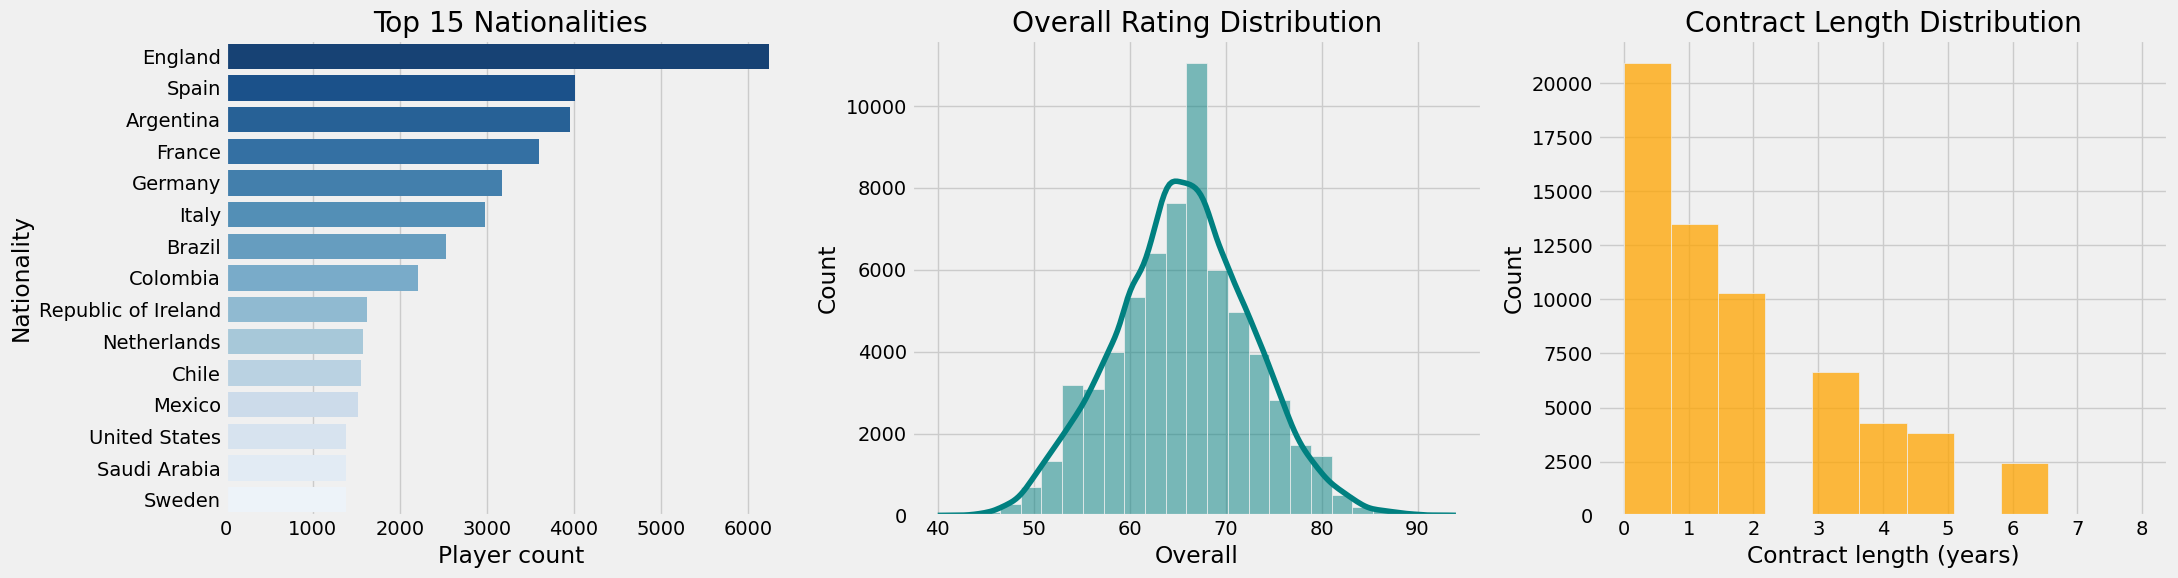

In [29]:
# Separate plots: nationality, overall, and contract length (from FIFA full data)

# Use the merged FIFA dataframe created above
df_plot = fifas_full_merged.copy()

# Detect likely column names
nat_col_candidates = ['nationality_name', 'nationality', 'nation']
overall_col = 'overall'
contract_col_candidates = ['contract_valid_until', 'contract_until', 'contract_end_year']

nat_col = next((c for c in nat_col_candidates if c in df_plot.columns), None)
contract_col = next((c for c in contract_col_candidates if c in df_plot.columns), None)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# 1) Nationality plot (top 15 by player count)
if nat_col is not None:
    top_nat = df_plot[nat_col].value_counts().head(15)
    sns.barplot(
        x=top_nat.values,
        y=top_nat.index,
        ax=axes[0],
        palette='Blues_r'
    )
    axes[0].set_title('Top 15 Nationalities')
    axes[0].set_xlabel('Player count')
    axes[0].set_ylabel('Nationality')
else:
    axes[0].text(0.5, 0.5, 'Nationality column not found', ha='center', va='center')
    axes[0].set_axis_off()

# 2) Overall rating distribution
if overall_col in df_plot.columns:
    sns.histplot(
        df_plot[overall_col].dropna(),
        bins=25,
        kde=True,
        ax=axes[1],
        color='teal'
    )
    axes[1].set_title('Overall Rating Distribution')
    axes[1].set_xlabel('Overall')
    axes[1].set_ylabel('Count')
else:
    axes[1].text(0.5, 0.5, 'Overall column not found', ha='center', va='center')
    axes[1].set_axis_off()

# 3) Contract length distribution (contract end year - season)
if (contract_col is not None) and ('Season' in df_plot.columns):
    contract_year = pd.to_numeric(df_plot[contract_col], errors='coerce')
    season_year = pd.to_numeric(df_plot['Season'], errors='coerce')
    df_plot['contract_length'] = contract_year - season_year
    df_plot = df_plot[(df_plot['contract_length'] >= 0) & (df_plot['contract_length'] <= 10)]

    sns.histplot(
        df_plot['contract_length'].dropna(),
        bins=11,
        kde=False,
        ax=axes[2],
        color='orange'
    )
    axes[2].set_title('Contract Length Distribution')
    axes[2].set_xlabel('Contract length (years)')
    axes[2].set_ylabel('Count')
else:
    axes[2].text(0.5, 0.5, 'Contract column not found', ha='center', va='center')
    axes[2].set_axis_off()

plt.tight_layout()
plt.show()

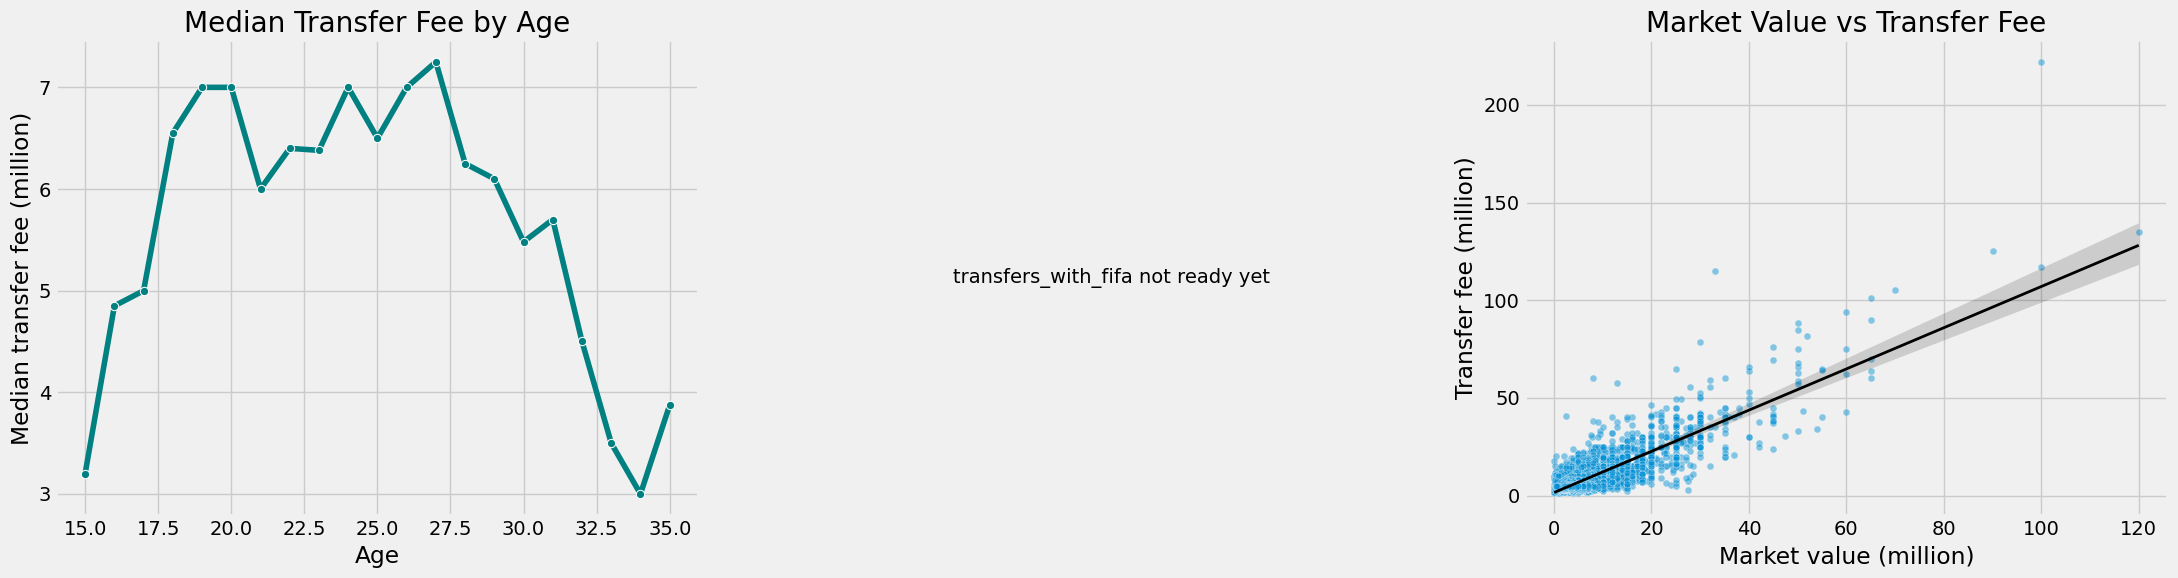

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# 1) Age vs median transfer fee
age_fee = (
    transfers_cleaned.groupby('Age', as_index=False)['Transfer_fee_in_mln']
    .median()
    .sort_values('Age')
)
sns.lineplot(data=age_fee, x='Age', y='Transfer_fee_in_mln', marker='o', ax=axes[0], color='teal')
axes[0].set_title('Median Transfer Fee by Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Median transfer fee (million)')

# 2) Potential vs current overall (if FIFA-enriched rows are available)
twf = globals().get('transfers_with_fifa', None)
required_cols = {'overall', 'potential', 'Transfer_fee_in_mln'}
if twf is not None and required_cols.issubset(set(twf.columns)):
    sns.scatterplot(
        data=twf,
        x='overall',
        y='potential',
        hue='Transfer_fee_in_mln',
        palette='viridis',
        alpha=0.75,
        ax=axes[1]
    )
    min_rating = int(min(twf['overall'].min(), twf['potential'].min()))
    max_rating = int(max(twf['overall'].max(), twf['potential'].max()))
    axes[1].plot([min_rating, max_rating], [min_rating, max_rating], linestyle='--', color='red', linewidth=1)
    axes[1].set_title('Potential vs Current Overall')
    axes[1].set_xlabel('Current overall')
    axes[1].set_ylabel('Potential')
    axes[1].legend(title='Transfer fee (million)', bbox_to_anchor=(1.02, 1), loc='upper left')
else:
    axes[1].text(0.5, 0.5, 'transfers_with_fifa not ready yet', ha='center', va='center')
    axes[1].set_axis_off()

# 3) Market value vs transfer fee
market_df = transfers_cleaned.dropna(subset=['Market_value_in_mln', 'Transfer_fee_in_mln'])
sns.scatterplot(
    data=market_df,
    x='Market_value_in_mln',
    y='Transfer_fee_in_mln',
    alpha=0.45,
    s=25,
    ax=axes[2]
)
sns.regplot(
    data=market_df,
    x='Market_value_in_mln',
    y='Transfer_fee_in_mln',
    scatter=False,
    color='black',
    line_kws={'linewidth': 2},
    ax=axes[2]
)
axes[2].set_title('Market Value vs Transfer Fee')
axes[2].set_xlabel('Market value (million)')
axes[2].set_ylabel('Transfer fee (million)')

plt.tight_layout()
plt.show()

# Actual Solution was done below

In [31]:
import zipfile

ratings_zip_path = '../data/ratings.zip'
usecols = ['short_name', 'overall', 'potential', 'club']

with zipfile.ZipFile(ratings_zip_path) as zf:
    fifa_15 = pd.read_csv(zf.open('players_15.csv'), usecols=usecols)
    fifa_16 = pd.read_csv(zf.open('players_16.csv'), usecols=usecols)
    fifa_17 = pd.read_csv(zf.open('players_17.csv'), usecols=usecols)
    fifa_18 = pd.read_csv(zf.open('players_18.csv'), usecols=usecols)

fifa_15['Season'] = 2015
fifa_16['Season'] = 2016
fifa_17['Season'] = 2017
fifa_18['Season'] = 2018

In [32]:
fifas_merged = pd.concat([fifa_15,fifa_16,fifa_17,fifa_18],ignore_index=True)
fifas_merged['Lastname'] = fifas_merged['short_name'].str.split(' ').str[-1]
fifas_merged = fifas_merged.drop(columns = ['short_name'])
fifas_merged.head()

,club,overall,potential,Season,Lastname
0,FC Barcelona,93,95,2015,Messi
1,Real Madrid,92,92,2015,Ronaldo
2,FC Bayern München,90,90,2015,Robben
3,Paris Saint-Germain,90,90,2015,Ibrahimović
4,FC Bayern München,90,90,2015,Neuer


In [33]:
!pip install fuzzywuzzy


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [34]:
from fuzzywuzzy import process
unique = transfers_cleaned_2015_18.Team_from.unique()
for team in fifas_merged.club.unique():
    for found, score in process.extract(team,unique,limit = 1):
        if score > 80:
            fifas_merged['club']=fifas_merged['club'].replace([team],found)

fifas_merged.head()

,club,overall,potential,Season,Lastname
0,FC Barcelona,93,95,2015,Messi
1,Real Madrid,92,92,2015,Ronaldo
2,FC Porto,90,90,2015,Robben
3,Paris SG,90,90,2015,Ibrahimović
4,FC Porto,90,90,2015,Neuer


In [35]:
fifas_merged['Lastname'] = fifas_merged['Lastname'].str.normalize('NFKD')\
       .str.encode('ascii', errors='ignore')\
       .str.decode('utf-8')
fifas_merged['club'] = fifas_merged['club'].str.normalize('NFKD')\
       .str.encode('ascii', errors='ignore')\
       .str.decode('utf-8')
transfers_cleaned_2015_18['Lastname'] = transfers_cleaned_2015_18['Lastname'].str.normalize('NFKD')\
       .str.encode('ascii', errors='ignore')\
       .str.decode('utf-8')
transfers_cleaned_2015_18['Team_from'] = transfers_cleaned_2015_18['Team_from'].str.normalize('NFKD')\
       .str.encode('ascii', errors='ignore')\
       .str.decode('utf-8')
transfers_cleaned_2015_18['Team_to'] = transfers_cleaned_2015_18['Team_to'].str.normalize('NFKD')\
       .str.encode('ascii', errors='ignore')\
       .str.decode('utf-8')

In [36]:
#fifas_merged['Lastname']=fifas_merged['Lastname'].replace(to_replace = '.*ić$',value = '.*ic$',regex = True)
fifas_merged['club']=fifas_merged['club'].replace(to_replace = ['FC Girondins de Bordeaux','Manchester United','Manchester City','Tottenham Hotspur','Olympique Lyonnais','Borussia Dortmund','Wolverhampton Wanderers','Galatasaray SK','FC Bayern München'],\
                                                  value = ['G. Bordeaux','Man Utd','Man City','Spurs','Olympique Lyon','Bor. Dortmund','Wolves','Galatasaray','Bayern Munich'])
fifas_merged['Lastname']=fifas_merged['Lastname'].replace(to_replace =['Yanga-M\'Biwa','Yılmaz','N\'Zonzi','Adama'],value = ['Yanga-Mbiwa','Yilmaz','Nzonzi','Traore'])

In [37]:
transfers_cleaned_with_fifa = transfers_cleaned_2015_18.merge(fifas_merged, how = 'left',left_on=['Lastname','Season_transferred','Team_from'],right_on=[ 'Lastname','Season','club'])
transfers_null = transfers_cleaned_with_fifa[transfers_cleaned_with_fifa['club'].isnull()]
transfers_null = transfers_null.drop(columns = ['club','overall','potential','Season'])
transfers_null_with_fifa = transfers_null.merge(fifas_merged, how = 'left',left_on=['Lastname','Season_transferred','Team_to'],right_on=[ 'Lastname','Season','club'])
transfers_with_fifa = pd.concat([transfers_cleaned_with_fifa,transfers_null_with_fifa],ignore_index = True).dropna()

In [38]:
print(transfers_with_fifa.shape)

(731, 14)


In [39]:
transfers_with_fifa

,Position,Age,Team_from,League_from,Team_to,League_to,Season_transferred,Transfer_fee_in_mln,Market_value_in_mln,Lastname,club,overall,potential,Season
0,Attacking Midfield,24,VfL Wolfsburg,1.Bundesliga,Man City,Premier League,2015,76.0,45.0,Bruyne,VfL Wolfsburg,81.0,86.0,2015.0
1,Right Winger,20,Liverpool,Premier League,Man City,Premier League,2015,63.7,40.0,Sterling,Liverpool,80.0,86.0,2015.0
2,Right Winger,27,Man Utd,Premier League,Paris SG,Ligue 1,2015,63.0,50.0,Maria,Man Utd,86.0,88.0,2015.0
3,Left Winger,19,Monaco,Ligue 1,Man Utd,Premier League,2015,60.0,8.0,Martial,Monaco,69.0,81.0,2015.0
4,Attacking Midfield,26,Shakhtar D.,Premier Liga,JS Suning,Super League,2015,50.0,30.0,Teixeira,Shakhtar D.,79.0,82.0,2015.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1322,Left Winger,27,Sunderland,League One,AC Milan,Serie A,2018,5.5,7.0,Borini,AC Milan,76.0,77.0,2018.0
1329,Central Midfield,23,Benfica,Liga NOS,Atalanta,Serie A,2018,5.0,25.0,Cristante,Atalanta,72.0,82.0,2018.0
1331,Right-Back,23,FC Ingolstadt,2.Bundesliga,Huddersfield,Premier League,2018,5.0,5.0,Hadergjonaj,Huddersfield,72.0,79.0,2018.0
1332,Right Winger,25,AS Roma,Serie A,Club Tijuana,Liga MX Apertura,2018,5.0,4.0,Iturbe,Club Tijuana,76.0,78.0,2018.0


## Feature engineering for fairness-focused analysis
The following cells create engineered features needed to evaluate geographic and systemic biases.
- Preserve sensitive attributes (`Nationality`, `League_to`).
- Create normalized/reduced categorical groups for stability (top-k / `Other`).
- Add numeric proxies (log fees, league strength, club spend) and demographic buckets for downstream fairness metrics.

In [40]:
# Feature engineering (1/4): setup and base frame
import os
import zipfile
import numpy as np
import pandas as pd

transfers_fe = transfers_with_fifa.copy()

# Backfill Name from transfer-market style transfer rows when missing
if 'Name' not in transfers_fe.columns and 'transfers_cleaned' in globals():
    name_lookup = (
        transfers_cleaned[transfers_cleaned['Season_transferred'] > 2014][
            ['Name', 'Position', 'Age', 'Team_from', 'Team_to', 'League_from', 'League_to',
             'Season_transferred', 'Transfer_fee_in_mln', 'Market_value_in_mln']
        ]
        .drop_duplicates()
    )
    transfers_fe = transfers_fe.merge(
        name_lookup,
        how='left',
        on=['Position', 'Age', 'Team_from', 'Team_to', 'League_from', 'League_to',
            'Season_transferred', 'Transfer_fee_in_mln', 'Market_value_in_mln']
    )

# Keep original Nationality availability for fallback diagnostics
if 'Nationality' not in transfers_fe.columns:
    transfers_fe['Nationality'] = np.nan

transfers_fe['_nat_before'] = transfers_fe['Nationality']

# Normalization helper reused across fallback stages
def _normalize_ascii(s):
    return (
        s.astype(str)
         .str.normalize('NFKD')
         .str.encode('ascii', errors='ignore')
         .str.decode('utf-8')
    )

print('Rows in transfers_fe:', len(transfers_fe))
print('Nationality nulls before fallback:', int(transfers_fe['_nat_before'].isna().sum()))

Rows in transfers_fe: 731
Nationality nulls before fallback: 731


In [41]:
# Feature engineering (2/4): build FIFA nationality lookup tables used by fallbacks
ratings_zip_path = '../data/ratings.zip'

nat_frames = []
with zipfile.ZipFile(ratings_zip_path) as zf:
    for yr in [2015, 2016, 2017, 2018]:
        f = pd.read_csv(zf.open(f'players_{yr-2000}.csv'))
        nat_col = 'nationality_name' if 'nationality_name' in f.columns else ('nationality' if 'nationality' in f.columns else None)
        if nat_col is None:
            continue

        keep_cols = ['short_name', 'club', nat_col]
        if 'overall' in f.columns:
            keep_cols.append('overall')

        mini = f[keep_cols].copy()
        mini['Lastname'] = mini['short_name'].str.split(' ').str[-1]
        mini['Season_transferred'] = yr
        mini = mini.rename(columns={nat_col: 'Nationality'})
        if 'overall' not in mini.columns:
            mini['overall'] = np.nan

        mini = mini[['Lastname', 'club', 'Season_transferred', 'Nationality', 'overall']]
        nat_frames.append(mini)

if nat_frames:
    fifa_nat = pd.concat(nat_frames, ignore_index=True).drop_duplicates()
    for c in ['Lastname', 'club', 'Nationality']:
        fifa_nat[c] = _normalize_ascii(fifa_nat[c])

    fifa_nat['_lastname_norm'] = fifa_nat['Lastname']
    fifa_nat = fifa_nat.sort_values('overall', ascending=False)

    # Best row per lastname+club+season (used for Team_from and Team_to lookups)
    fifa_nat_best_club = fifa_nat.drop_duplicates(
        subset=['_lastname_norm', 'club', 'Season_transferred'],
        keep='first'
    )

    # Best row per lastname+season (used as broader fallback)
    fifa_nat_best_name_season = fifa_nat.drop_duplicates(
        subset=['_lastname_norm', 'Season_transferred'],
        keep='first'
    )

    print('FIFA lookup rows (club-level):', len(fifa_nat_best_club))
    print('FIFA lookup rows (lastname-season):', len(fifa_nat_best_name_season))
else:
    fifa_nat_best_club = pd.DataFrame(columns=['_lastname_norm', 'club', 'Season_transferred', 'Nationality'])
    fifa_nat_best_name_season = pd.DataFrame(columns=['_lastname_norm', 'Season_transferred', 'Nationality'])
    print('No FIFA nationality frames found; fallback will not enrich Nationality.')

FIFA lookup rows (club-level): 63797
FIFA lookup rows (lastname-season): 46302


In [42]:
# Feature engineering (3/4): apply fallback matching for Nationality and test coverage
merge_base_cols = ['Lastname', 'Team_from', 'Team_to', 'Season_transferred']
if all(c in transfers_fe.columns for c in merge_base_cols):
    transfers_fe['_lastname_norm'] = _normalize_ascii(transfers_fe['Lastname'])
    transfers_fe['_team_from_norm'] = _normalize_ascii(transfers_fe['Team_from'])
    transfers_fe['_team_to_norm'] = _normalize_ascii(transfers_fe['Team_to'])

    # 1) Fallback from Team_from
    from_lookup = fifa_nat_best_club.rename(columns={'club': '_team_from_norm', 'Nationality': 'nat_from'})[
        ['_lastname_norm', '_team_from_norm', 'Season_transferred', 'nat_from']
    ]
    transfers_fe = transfers_fe.merge(
        from_lookup,
        how='left',
        on=['_lastname_norm', '_team_from_norm', 'Season_transferred']
    )

    # 2) Fallback from Team_to
    to_lookup = fifa_nat_best_club.rename(columns={'club': '_team_to_norm', 'Nationality': 'nat_to'})[
        ['_lastname_norm', '_team_to_norm', 'Season_transferred', 'nat_to']
    ]
    transfers_fe = transfers_fe.merge(
        to_lookup,
        how='left',
        on=['_lastname_norm', '_team_to_norm', 'Season_transferred']
    )

    # 3) Lastname + season fallback
    last_season_lookup = fifa_nat_best_name_season.rename(columns={'Nationality': 'nat_last_season'})[
        ['_lastname_norm', 'Season_transferred', 'nat_last_season']
    ]
    transfers_fe = transfers_fe.merge(
        last_season_lookup,
        how='left',
        on=['_lastname_norm', 'Season_transferred']
    )

    existing_nat = transfers_fe['_nat_before']
    transfers_fe['Nationality'] = existing_nat.combine_first(transfers_fe['nat_from'])
    transfers_fe['Nationality'] = transfers_fe['Nationality'].combine_first(transfers_fe['nat_to'])
    transfers_fe['Nationality'] = transfers_fe['Nationality'].combine_first(transfers_fe['nat_last_season'])

    transfers_fe['nationality_match_source'] = np.select(
        [
            existing_nat.notna(),
            existing_nat.isna() & transfers_fe['nat_from'].notna(),
            existing_nat.isna() & transfers_fe['nat_from'].isna() & transfers_fe['nat_to'].notna(),
            existing_nat.isna() & transfers_fe['nat_from'].isna() & transfers_fe['nat_to'].isna() & transfers_fe['nat_last_season'].notna()
        ],
        [
            'existing',
            'fallback_team_from',
            'fallback_team_to',
            'fallback_lastname_season'
        ],
        default='unresolved'
    )

    nat_before = int(existing_nat.isna().sum())
    nat_after = int(transfers_fe['Nationality'].isna().sum())
    print('Nationality nulls before fallback:', nat_before)
    print('Nationality nulls after fallback:', nat_after)
    print('Recovered rows:', nat_before - nat_after)

    cleanup_cols = [
        '_nat_before', '_lastname_norm', '_team_from_norm', '_team_to_norm',
        'nat_from', 'nat_to', 'nat_last_season'
    ]
    transfers_fe = transfers_fe.drop(columns=[c for c in cleanup_cols if c in transfers_fe.columns])
else:
    transfers_fe['nationality_match_source'] = np.where(
        transfers_fe['Nationality'].notna(),
        'existing',
        'unresolved'
    )
    transfers_fe = transfers_fe.drop(columns=[c for c in ['_nat_before'] if c in transfers_fe.columns])
    print('Fallback keys missing; kept current Nationality values only.')

Nationality nulls before fallback: 731
Nationality nulls after fallback: 2
Recovered rows: 729


In [43]:
# Feature engineering (4/4): remaining engineered features + save exports
# Sensitive attributes we will use for subgroup analysis
sensitive_cols = [c for c in ['Nationality', 'League_to'] if c in transfers_fe.columns]
print('Sensitive cols available:', sensitive_cols)

# Log-transform of transfer fee to stabilise variance
transfers_fe['log_transfer_fee'] = np.log1p(transfers_fe['Transfer_fee_in_mln'])

# Fee minus market value (already computed earlier in parts of the notebook)
if 'fee_minus_value' not in transfers_fe.columns:
    transfers_fe['fee_minus_value'] = transfers_fe['Transfer_fee_in_mln'] - transfers_fe.get('Market_value_in_mln', pd.Series(0, index=transfers_fe.index)).fillna(0)

# New feature: market value divided by FIFA potential (safe divide)
if 'Market_value_in_mln' in transfers_fe.columns and 'potential' in transfers_fe.columns:
    potential_num = pd.to_numeric(transfers_fe['potential'], errors='coerce')
    mv_num = pd.to_numeric(transfers_fe['Market_value_in_mln'], errors='coerce')
    transfers_fe['market_value_per_potential'] = np.where(
        potential_num > 0,
        mv_num / potential_num,
        np.nan
    )

# Nationality ranking buckets: Top 1-15, 16-30, 31-45, Outside Top 45
if 'Nationality' in transfers_fe.columns:
    nat_counts = transfers_fe['Nationality'].value_counts()
    top15 = nat_counts.head(15).index
    top30 = nat_counts.head(30).index
    top45 = nat_counts.head(45).index
    transfers_fe['Nationality_bucket'] = np.select(
        [
            transfers_fe['Nationality'].isin(top15),
            transfers_fe['Nationality'].isin(top30),
            transfers_fe['Nationality'].isin(top45)
        ],
        ['Top 1-15', 'Top 16-30', 'Top 31-45'],
        default='Outside Top 45'
    )

# League strength: median transfer fee by destination league (proxy for purchasing power)
if 'League_to' in transfers_fe.columns:
    league_median = transfers_fe.groupby('League_to')['Transfer_fee_in_mln'].median()
    transfers_fe['league_median_fee_to'] = transfers_fe['League_to'].map(league_median)

# Team spend proxy: median incoming transfer fee per destination team
if 'Team_to' in transfers_fe.columns:
    team_median = transfers_fe.groupby('Team_to')['Transfer_fee_in_mln'].median()
    transfers_fe['team_to_median_fee'] = transfers_fe['Team_to'].map(team_median)

# Age buckets (helpful for confounding control)
if 'Age' in transfers_fe.columns:
    transfers_fe['age_bucket'] = pd.cut(transfers_fe['Age'], bins=[14,20,24,27,30,50], labels=['<20','20-23','24-26','27-29','30+'])

# Position buckets for subgroup and fairness analysis
if 'Position' in transfers_fe.columns:
    pos = transfers_fe['Position'].fillna('').str.lower()
    transfers_fe['position_bucket'] = np.select(
        [
            pos.str.contains('goalkeeper'),
            pos.str.contains('back|defender|sweeper'),
            pos.str.contains('midfield'),
            pos.str.contains('winger'),
            pos.str.contains('forward|striker')
        ],
        ['Goalkeeper', 'Defender', 'Midfielder', 'Winger', 'Forward'],
        default='Other'
    )

# Nationality vs destination-league country match feature
league_country_map = {
    'premier league': 'England',
    'championship': 'England',
    'league one': 'England',
    'premiership': 'Scotland',
    'laliga': 'Spain',
    'segunda division': 'Spain',
    'serie a': 'Italy',
    'serie b': 'Italy',
    '1.bundesliga': 'Germany',
    '2.bundesliga': 'Germany',
    'ligue 1': 'France',
    'eredi': 'Netherlands',
    'liga nos': 'Portugal',
    'super league': 'China',
    'super lig': 'Turkey',
    'sueper lig': 'Turkey',
    'sueper': 'Turkey',
    'liga mx': 'Mexico',
    'mls': 'United States',
    'j1 league': 'Japan',
    'uae gulf league': 'United Arab Emirates',
    'professional league': 'Saudi Arabia',
    'premier liga': 'Ukraine',
    'primera division': 'Argentina'
}

def _league_to_country(league_name):
    if pd.isna(league_name):
        return np.nan
    league_name_l = str(league_name).lower()
    for key, country in league_country_map.items():
        if key in league_name_l:
            return country
    return np.nan

if 'League_to' in transfers_fe.columns:
    transfers_fe['league_country_to'] = transfers_fe['League_to'].apply(_league_to_country)
if 'Nationality' in transfers_fe.columns and 'league_country_to' in transfers_fe.columns:
    nat_norm = transfers_fe['Nationality'].astype(str).str.strip().str.lower()
    country_norm = transfers_fe['league_country_to'].astype(str).str.strip().str.lower()
    transfers_fe['nationality_matches_league_to'] = pd.Series(
        np.where(
            transfers_fe['Nationality'].notna() & transfers_fe['league_country_to'].notna(),
            nat_norm == country_norm,
            np.nan
        ),
        index=transfers_fe.index
    ).astype('boolean')

# High/low FIFA overall as a proxy for ability (if available)
if 'overall' in transfers_fe.columns:
    transfers_fe['high_overall'] = transfers_fe['overall'] >= transfers_fe['overall'].median()

# Top-club indicators for destination clubs and leagues
if 'Team_to' in transfers_fe.columns:
    top_clubs = transfers_fe['Team_to'].value_counts().head(20).index
    transfers_fe['is_top_club_to'] = transfers_fe['Team_to'].isin(top_clubs)
if 'League_to' in transfers_fe.columns:
    top_leagues = transfers_fe['League_to'].value_counts().head(10).index
    transfers_fe['is_top_league'] = transfers_fe['League_to'].isin(top_leagues)

# Prepare a minimal preview of engineered columns for inspection
preview_cols = [
    c for c in [
        'Name', 'Nationality', 'nationality_match_source', 'Nationality_bucket',
        'log_transfer_fee', 'fee_minus_value',
        'Market_value_in_mln', 'potential', 'market_value_per_potential',
        'Position', 'position_bucket', 'league_country_to', 'nationality_matches_league_to',
        'league_median_fee_to', 'team_to_median_fee', 'age_bucket',
        'is_top_club_to', 'is_top_league', 'high_overall'
    ] if c in transfers_fe.columns
]
display(transfers_fe[preview_cols].head())

# Save engineered dataset for downstream modeling and fairness checks
out_dir = '../data/processed'
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, 'transfers_engineered.csv')
transfers_fe.to_csv(out_path, index=False)
print('Saved engineered dataset to', out_path)

Sensitive cols available: ['Nationality', 'League_to']


,Name,Nationality,nationality_match_source,Nationality_bucket,log_transfer_fee,fee_minus_value,Market_value_in_mln,potential,market_value_per_potential,Position,position_bucket,league_country_to,nationality_matches_league_to,league_median_fee_to,team_to_median_fee,age_bucket,is_top_club_to,is_top_league,high_overall
0,Kevin De Bruyne,Belgium,fallback_team_from,Top 1-15,4.343805,31.0,45.0,86.0,0.523256,Attacking Midfield,Midfielder,England,False,15.1,50.0,20-23,True,True,True
1,Raheem Sterling,England,fallback_team_from,Top 1-15,4.169761,23.7,40.0,86.0,0.465116,Right Winger,Winger,England,True,15.1,50.0,<20,True,True,True
2,Ángel Di María,Argentina,fallback_lastname_season,Top 1-15,4.158883,13.0,50.0,88.0,0.568182,Right Winger,Winger,France,False,10.0,25.0,24-26,True,True,True
3,Anthony Martial,France,fallback_lastname_season,Top 1-15,4.110874,52.0,8.0,81.0,0.098765,Left Winger,Winger,England,False,15.1,40.0,<20,True,True,False
4,Alex Teixeira,Brazil,fallback_lastname_season,Top 1-15,3.931826,20.0,30.0,82.0,0.365854,Attacking Midfield,Midfielder,China,False,13.5,28.0,24-26,False,True,True


Saved engineered dataset to ../data/processed/transfers_engineered.csv


In [44]:
# Inspect subgroup sizes for sensitive attributes to guide fairness metric selection
if 'nationality_match_source' in transfers_fe.columns:
    print('Nationality match source counts:')
    display(transfers_fe['nationality_match_source'].value_counts(dropna=False))

if 'Nationality' in transfers_fe.columns:
    nat_nulls = int(transfers_fe['Nationality'].isna().sum())
    nat_total = len(transfers_fe)
    print(f'Nationality nulls after fallback: {nat_nulls} / {nat_total} ({nat_nulls / nat_total:.1%})')

if 'Nationality_bucket' in transfers_fe.columns:
    print('Nationality bucket counts:')
    display(transfers_fe['Nationality_bucket'].value_counts(dropna=False))
if 'League_to' in transfers_fe.columns:
    print('League_to counts (top groups):')
    display(transfers_fe['League_to'].value_counts().head(30))

if 'nationality_matches_league_to' in transfers_fe.columns:
    print('Nationality vs destination-league country match rate:')
    display(transfers_fe['nationality_matches_league_to'].value_counts(dropna=False))

if 'market_value_per_potential' in transfers_fe.columns:
    print('Market value per potential summary:')
    display(transfers_fe['market_value_per_potential'].describe())

# Save a compact version of sensitive + engineered columns for quick fairness checks
compact_cols = [
    c for c in [
        'Name', 'Nationality', 'nationality_match_source', 'Nationality_bucket',
        'Transfer_fee_in_mln', 'log_transfer_fee', 'fee_minus_value',
        'Market_value_in_mln', 'potential', 'market_value_per_potential',
        'position_bucket', 'league_country_to', 'nationality_matches_league_to',
        'League_to', 'age_bucket', 'is_top_club_to', 'is_top_league', 'high_overall'
    ] if c in transfers_fe.columns
]
transfers_fe[compact_cols].to_csv(os.path.join(out_dir, 'transfers_engineered_compact.csv'), index=False)
print('Saved compact engineered file for fairness checks to', os.path.join(out_dir, 'transfers_engineered_compact.csv'))

Nationality match source counts:


nationality_match_source
fallback_team_from          354
fallback_lastname_season    337
fallback_team_to             38
unresolved                    2
Name: count, dtype: int64

Nationality nulls after fallback: 2 / 731 (0.3%)
Nationality bucket counts:


Nationality_bucket
Top 1-15          539
Top 16-30         105
Top 31-45          53
Outside Top 45     34
Name: count, dtype: int64

League_to counts (top groups):


...

Nationality vs destination-league country match rate:


nationality_matches_league_to
False    544
True     175
<NA>      12
Name: count, dtype: Int64

Market value per potential summary:


count    731.000000
mean       0.151620
std        0.139247
min        0.001974
25%        0.073171
50%        0.105882
75%        0.182927
max        1.276596
Name: market_value_per_potential, dtype: float64

Saved compact engineered file for fairness checks to ../data/processed/transfers_engineered_compact.csv


In [45]:
transfers_fe.columns

Index(['Position', 'Age', 'Team_from', 'League_from', 'Team_to', 'League_to',
       'Season_transferred', 'Transfer_fee_in_mln', 'Market_value_in_mln',
       'Lastname', 'club', 'overall', 'potential', 'Season', 'Name',
       'Nationality', 'nationality_match_source', 'log_transfer_fee',
       'fee_minus_value', 'market_value_per_potential', 'Nationality_bucket',
       'league_median_fee_to', 'team_to_median_fee', 'age_bucket',
       'position_bucket', 'league_country_to', 'nationality_matches_league_to',
       'high_overall', 'is_top_club_to', 'is_top_league'],
      dtype='str')

We end up with 731 rows, which is about 73% of the data we started with. This is short of the 75% threshold that was set, and missing an already low threshold may affect model performance having less data to train with. 

We will run a random forest regressor with all the data this time. To reduce the number of features, we drop the leagues as the leagues and teams are heavily correlated.


In [46]:
transfers_fifa_without_name = transfers_with_fifa.drop(columns = ['club','Season','League_from','League_to'])
transfers_fifa_without_name = pd.get_dummies(transfers_fifa_without_name)
y2= transfers_fifa_without_name['Transfer_fee_in_mln']
X2= transfers_fifa_without_name.drop(columns = ['Transfer_fee_in_mln'])

Work on Feature Engineering from here:

In [47]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2,y2, random_state = 169,test_size = 0.3)
print(X_train2.shape)
print(X_test2.shape)
print(y_train2.shape)
print(y_test2.shape)
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor(n_estimators = 270,max_features = 650, random_state =169)
fit2 = rfr.fit(X_train2,y_train2)
y_pred2 = rfr.predict(X_test2)

mse2 = mean_squared_error(y_test2,y_pred2)
r2score2 = r2_score(y_test2,y_pred2) 
print(mse2)
print(r2score2)

(511, 941)
(220, 941)
(511,)
(220,)
48.71135510645338
0.796827602268237


We get an accuracy value of **80.0%** which is not too bad for a first try.

The following should be noted with regards to the accuracy and the quality of results:

**1. The transfer fee of a player is heavily correlated to their market value, rather than their overall/potential.**

In an earlier run, initialising the RF regressor, I was only able to obtain about 44% accuracy when dropping the market value column (please try it out for yourself too!). This is interesting as if we assume that FIFA ratings are a somewhat accurate representation of conventional opinions of player current and future ability, that the market valuations of players are very much divorced from the actual price a player is sold for. I initially assumed that market value and FIFA judgments of ability were rather correlated, which explains why I wanted to drop the feature. It turns out that both market value and FIFA ratings are far from correlated. 

If we compare our results from the first linear regression (which admittedly is a much simpler model), the effect of adding market value as a consideration far outweighs the effect of adding the FIFA ratings to the model. Should we take heart in the wisdom of the FIFA experts, it is very much possible that teams could be overpaying and/or getting bargains for players in the transfer market.

**2. This model is REALLY limited.**

This model suffers from a lack of data with only three years' worth of transfer data present, of which only 73% was used due to difficulties in the data cleaning process. Furthermore, FIFA ratings are insufficient in determining the ability of a player, and composite measures (maybe football stats from Opta) would give a more accurate picture of how good/bad a player is. With more data, the model can be improved to a higher accuracy.

**3. Our model is affected by the outliers heavily.**

Our mean-squared error stands at about 47.90, which makes for a root mean-squared-error of about 6.92million. Looking at the previous scatterplot of market value against transfer fees, we see that many players are sold for below 25 million. A rmse of roughly 7 million would thus be rather significant to the predictions given by the model.

However, taking into the context of the previous data analysis, 2015-2018 was when most of the outliers on the graph popped up, and the error in predicting big-money transfers such as Neymar's, Mbappe's, Coutinho's etc which all cost above of 100 million would push up the rmse. The accuracy of 80.0% should be focused on instead rather than the mse metric in this case due to the wide variation of transfer fees at one end of the spectrum.

# Fairness evaluation of the Random Forest model

Following the metrics plan in `docs/fairness-metrics-plan.md`, we evaluate whether the RF regressor's transfer-fee predictions are **systematically biased** across demographic groups.

We examine:
1. **Signed residual** (mean and median) — which groups are over- vs underpredicted
2. **MAE and RMSE** — which groups suffer larger prediction errors
3. **Calibration by predicted-fee bin** — at comparable predicted fees, do errors differ by group

Subgroups: **League_from**, **Nationality** (minimum n ≥ 20), and **Region** (aggregated nationality).

In [48]:
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns

# ── Build evaluation dataframe from the RF test set ──────────────────────────
eval_df = transfers_with_fifa.loc[X_test2.index].copy()
eval_df['y_true'] = y_test2.values
eval_df['y_pred'] = y_pred2
eval_df['residual'] = eval_df['y_pred'] - eval_df['y_true']
eval_df['abs_error'] = eval_df['residual'].abs()

# ── Load Nationality from FIFA data ──────────────────────────────────────────
_nat_frames = []
with zipfile.ZipFile('../data/ratings.zip') as zf:
    for yr in [2015, 2016, 2017, 2018]:
        f = pd.read_csv(zf.open(f'players_{yr - 2000}.csv'))
        nat_col = next(
            (c for c in ['nationality_name', 'nationality'] if c in f.columns),
            None,
        )
        if nat_col is None:
            continue
        mini = f[['short_name', nat_col]].copy()
        mini.columns = ['short_name', 'Nationality']
        mini['Lastname'] = (
            mini['short_name']
            .str.split(' ').str[-1]
            .str.normalize('NFKD')
            .str.encode('ascii', errors='ignore')
            .str.decode('utf-8')
        )
        mini['_season'] = yr
        _nat_frames.append(mini[['Lastname', '_season', 'Nationality']].drop_duplicates())

_nat_lookup = (
    pd.concat(_nat_frames, ignore_index=True)
    .drop_duplicates(subset=['Lastname', '_season'], keep='first')
)

eval_df['_season'] = eval_df['Season'].astype(int)
eval_df = eval_df.merge(_nat_lookup, how='left', on=['Lastname', '_season']).drop(columns=['_season'])

# ── Region mapping (manual aggregation for small-n nationalities) ────────────
REGION_MAP = {
    'Brazil': 'South America', 'Argentina': 'South America',
    'Colombia': 'South America', 'Uruguay': 'South America',
    'Chile': 'South America', 'Paraguay': 'South America',
    'Ecuador': 'South America', 'Peru': 'South America',
    'Venezuela': 'South America',
    'France': 'W. Europe', 'Spain': 'W. Europe', 'Germany': 'W. Europe',
    'Italy': 'W. Europe', 'Portugal': 'W. Europe',
    'Netherlands': 'W. Europe', 'Belgium': 'W. Europe',
    'England': 'W. Europe', 'Switzerland': 'W. Europe',
    'Austria': 'W. Europe', 'Scotland': 'W. Europe', 'Wales': 'W. Europe',
    'Republic of Ireland': 'W. Europe', 'Denmark': 'W. Europe',
    'Sweden': 'W. Europe', 'Norway': 'W. Europe', 'Finland': 'W. Europe',
    'Poland': 'E. Europe', 'Czech Republic': 'E. Europe',
    'Croatia': 'E. Europe', 'Serbia': 'E. Europe',
    'Bosnia Herzegovina': 'E. Europe', 'Romania': 'E. Europe',
    'Hungary': 'E. Europe', 'Slovakia': 'E. Europe',
    'Slovenia': 'E. Europe', 'Bulgaria': 'E. Europe',
    'Ukraine': 'E. Europe', 'Russia': 'E. Europe',
    'Greece': 'E. Europe', 'Turkey': 'E. Europe',
    'Albania': 'E. Europe', 'Montenegro': 'E. Europe',
    'Georgia': 'E. Europe',
    'Senegal': 'Africa', 'Ivory Coast': 'Africa',
    "Côte d'Ivoire": 'Africa', 'Ghana': 'Africa',
    'Nigeria': 'Africa', 'Cameroon': 'Africa',
    'DR Congo': 'Africa', 'Mali': 'Africa', 'Guinea': 'Africa',
    'Gabon': 'Africa', 'Morocco': 'Africa', 'Algeria': 'Africa',
    'Tunisia': 'Africa', 'Egypt': 'Africa', 'Congo': 'Africa',
    'Mexico': 'Americas (other)', 'United States': 'Americas (other)',
    'Canada': 'Americas (other)', 'Jamaica': 'Americas (other)',
    'Costa Rica': 'Americas (other)', 'Honduras': 'Americas (other)',
    'Japan': 'Asia & Oceania', 'South Korea': 'Asia & Oceania',
    'Australia': 'Asia & Oceania', 'Iran': 'Asia & Oceania',
}
eval_df['Region'] = eval_df['Nationality'].map(REGION_MAP).fillna('Other')

MIN_N = 20

print(f"Evaluation set: {len(eval_df)} transfers")
print(f"Nationality coverage: {eval_df['Nationality'].notna().sum()} / {len(eval_df)}")
print(f"\nRegion distribution:")
print(eval_df['Region'].value_counts())
print(f"\nLeague_from distribution:")
print(eval_df['League_from'].value_counts())

Evaluation set: 220 transfers
Nationality coverage: 220 / 220

Region distribution:
Region
W. Europe           129
South America        40
Africa               23
E. Europe            18
Other                 4
Asia & Oceania        3
Americas (other)      3
Name: count, dtype: int64

League_from distribution:
League_from
Premier League         41
Serie A                30
LaLiga                 28
Ligue 1                25
Championship           18
1.Bundesliga           14
Jupiler Pro League     10
Liga NOS               10
Primera División        8
Eredivisie              8
Premier Liga            5
2.Bundesliga            3
Süper Lig               3
Ligue 2                 2
Bundesliga              2
Super League            2
Professional League     2
Serie B                 2
Liga MX Apertura        2
UAE Gulf League         1
LaLiga2                 1
1.HNL                   1
Rel. Ligue 1            1
League One              1
Name: count, dtype: int64


=== Signed residual by League_from ===


,n,mean_residual,median_residual
League_from,,,
Premier League,41,-2.545,0.289
Ligue 1,25,-2.018,-2.634
LaLiga,28,-1.278,0.563
Serie A,30,0.399,0.200



=== Signed residual by Nationality (n ≥ 20) ===


,n,mean_residual,median_residual
Nationality,,,
Brazil,20,-5.818,-2.869
Spain,21,-0.256,0.729
France,31,-0.223,-1.048



=== Signed residual by Region ===


,n,mean_residual,median_residual
Region,,,
Africa,23,-3.709,-1.981
South America,40,-3.362,-0.952
E. Europe,18,-0.615,0.256
W. Europe,129,0.293,0.289


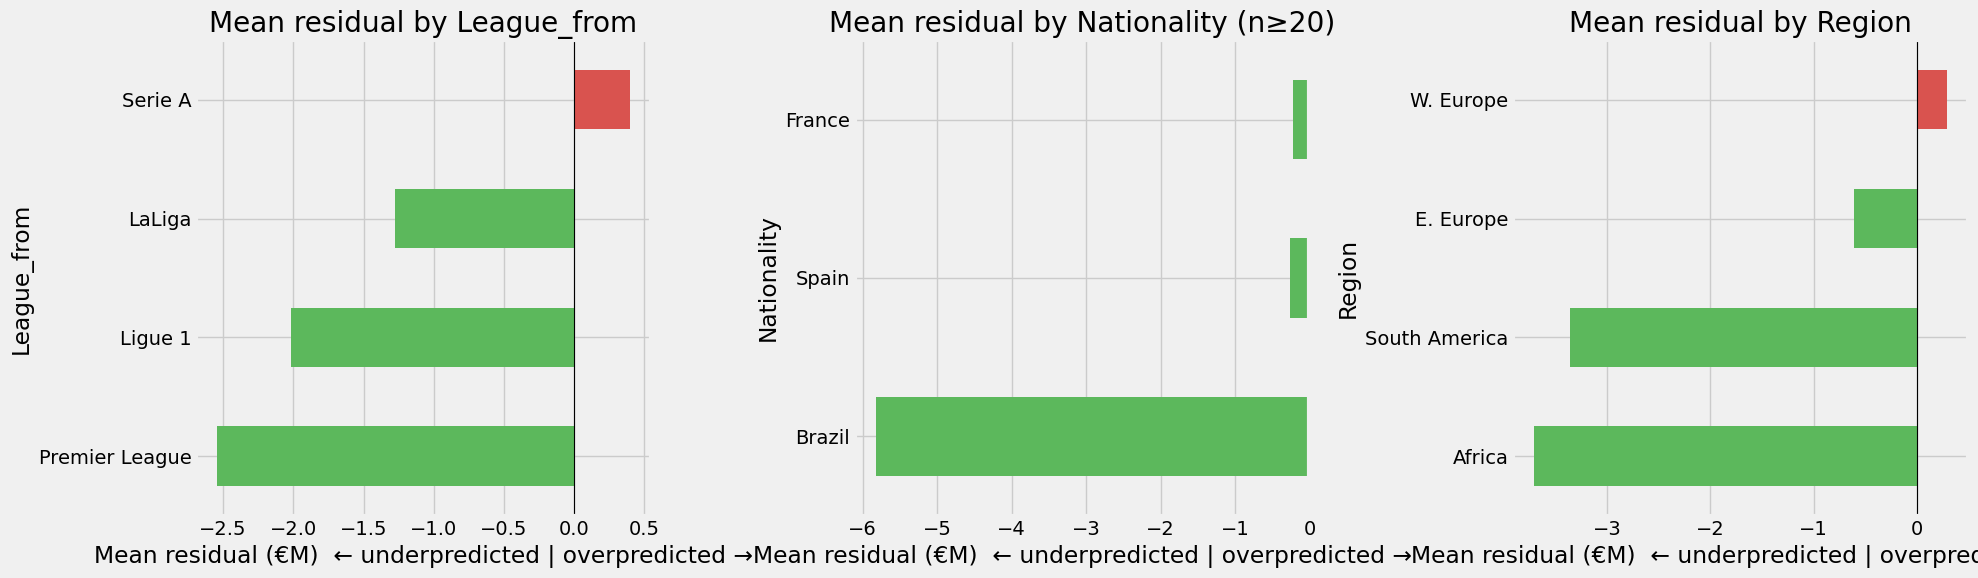

In [49]:
# ── Metric 1: Signed residual — who is over/underpredicted? ──────────────────

def residual_summary(df, group_col, min_n=MIN_N):
    """Mean and median signed residual per group, filtered by min sample size."""
    stats = (
        df.groupby(group_col)['residual']
        .agg(['count', 'mean', 'median'])
        .rename(columns={'count': 'n', 'mean': 'mean_residual', 'median': 'median_residual'})
    )
    return stats[stats['n'] >= min_n].sort_values('mean_residual').round(3)

print("=== Signed residual by League_from ===")
league_res = residual_summary(eval_df, 'League_from')
display(league_res)

print(f"\n=== Signed residual by Nationality (n ≥ {MIN_N}) ===")
nat_res = residual_summary(eval_df, 'Nationality')
display(nat_res)

print("\n=== Signed residual by Region ===")
region_res = residual_summary(eval_df, 'Region', min_n=5)
display(region_res)

# ── Charts ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, data, title in [
    (axes[0], league_res, 'Mean residual by League_from'),
    (axes[1], nat_res,    f'Mean residual by Nationality (n≥{MIN_N})'),
    (axes[2], region_res, 'Mean residual by Region'),
]:
    colors = ['#d9534f' if v > 0 else '#5cb85c' for v in data['mean_residual']]
    data['mean_residual'].plot.barh(ax=ax, color=colors)
    ax.set_title(title)
    ax.set_xlabel('Mean residual (€M)  ← underpredicted | overpredicted →')
    ax.axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

=== MAE / RMSE by League_from ===


,n,MAE,RMSE
League_from,,,
Premier League,41,6.508,10.413
LaLiga,28,6.335,8.270
Ligue 1,25,5.822,8.008
Serie A,30,3.498,5.266



=== MAE / RMSE by Nationality (n ≥ 20) ===


,n,MAE,RMSE
Nationality,,,
Brazil,20,7.284,13.343
France,31,5.977,8.124
Spain,21,4.284,5.536



=== MAE / RMSE by Region ===


,n,MAE,RMSE
Region,,,
Africa,23,5.553,7.275
South America,40,5.012,9.747
E. Europe,18,4.691,6.364
W. Europe,129,4.316,6.166


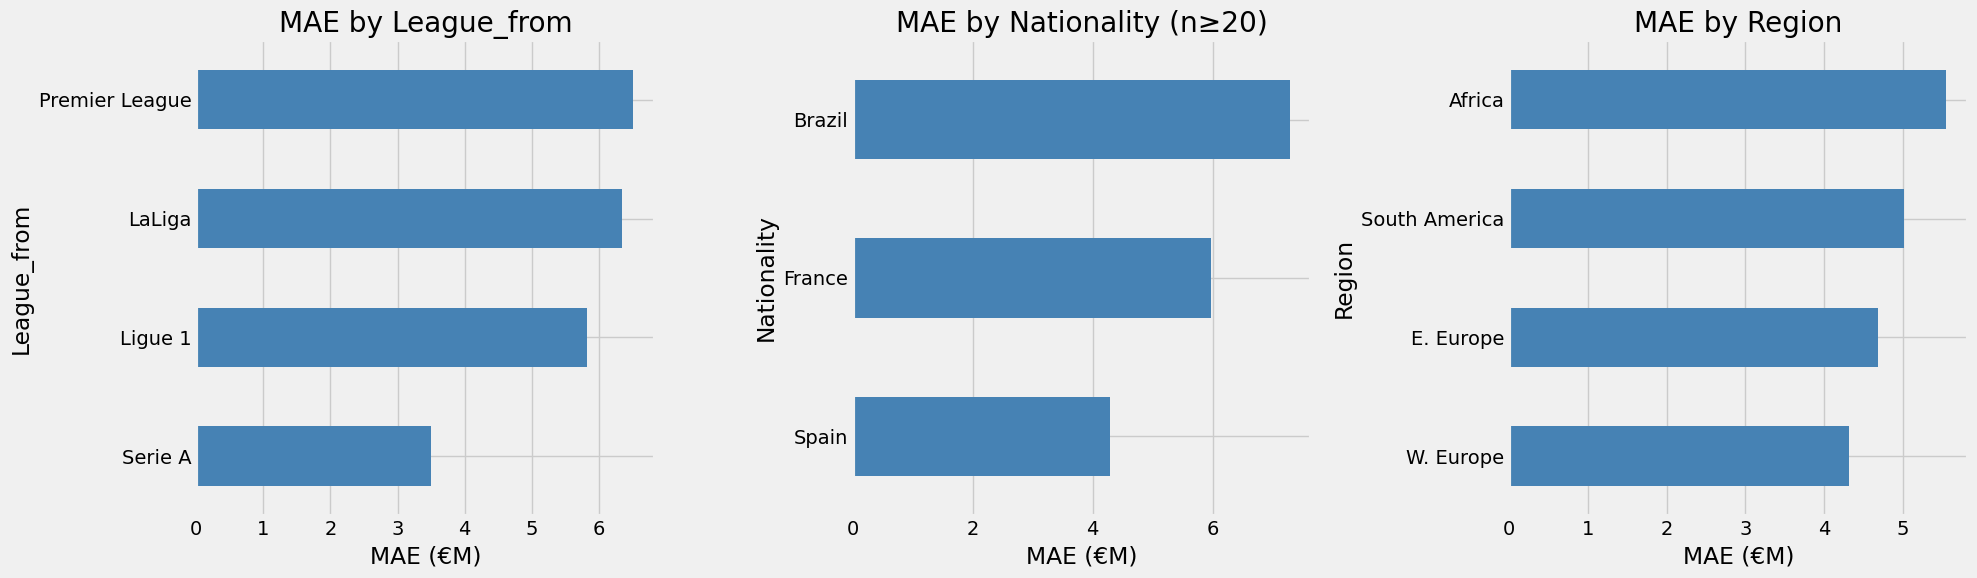

In [50]:
# ── Metric 2: MAE / RMSE — who gets the largest errors? ──────────────────────

def error_summary(df, group_col, min_n=MIN_N):
    """MAE and RMSE per group, filtered by min sample size."""
    stats = df.groupby(group_col).agg(
        n=('residual', 'count'),
        MAE=('abs_error', 'mean'),
        RMSE=('residual', lambda x: np.sqrt((x ** 2).mean())),
    )
    return stats[stats['n'] >= min_n].sort_values('MAE', ascending=False).round(3)

print("=== MAE / RMSE by League_from ===")
league_err = error_summary(eval_df, 'League_from')
display(league_err)

print(f"\n=== MAE / RMSE by Nationality (n ≥ {MIN_N}) ===")
nat_err = error_summary(eval_df, 'Nationality')
display(nat_err)

print("\n=== MAE / RMSE by Region ===")
region_err = error_summary(eval_df, 'Region', min_n=5)
display(region_err)

# ── Charts ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, data, title in [
    (axes[0], league_err, 'MAE by League_from'),
    (axes[1], nat_err,    f'MAE by Nationality (n≥{MIN_N})'),
    (axes[2], region_err, 'MAE by Region'),
]:
    data['MAE'].sort_values().plot.barh(ax=ax, color='steelblue')
    ax.set_title(title)
    ax.set_xlabel('MAE (€M)')

plt.tight_layout()
plt.show()

=== Mean residual by predicted-fee quintile × Region ===


mean_residual   n
pred_bin          Region                             
(5.885, 8.47]     Africa                   -2.453   5
                  Americas (other)         -2.066   2
                  Asia & Oceania           -0.510   2
                  E. Europe                 0.261   1
                  Other                     1.205   1
                  South America            -1.538  10
                  W. Europe                -1.334  23
(8.47, 10.354]    Africa                   -1.332   4
                  Americas (other)         -1.013   1
                  Asia & Oceania            0.617   1
                  E. Europe                -2.744   3
                  Other                     2.921   2
                  South America             1.100   9
                  W. Europe                -0.335  24
(10.354, 12.278]  Africa                   -0.005   6
                  E. Europe                -3.558   5
                  South America            -0.336   5
                  W. Europe                -0.579  28
(12.278, 20.344]  Africa                   -4.486   5
                  E. Europe                 1.457   6
                  South America            -1.136   6
                  W. Europe                 1.781  27
(20.344, 114.738] Africa                  -15.086   3
                  E. Europe                 1.984   3
                  Other                    -5.046   1
                  South America           -12.048  10
                  W. Europe                 1.653  27

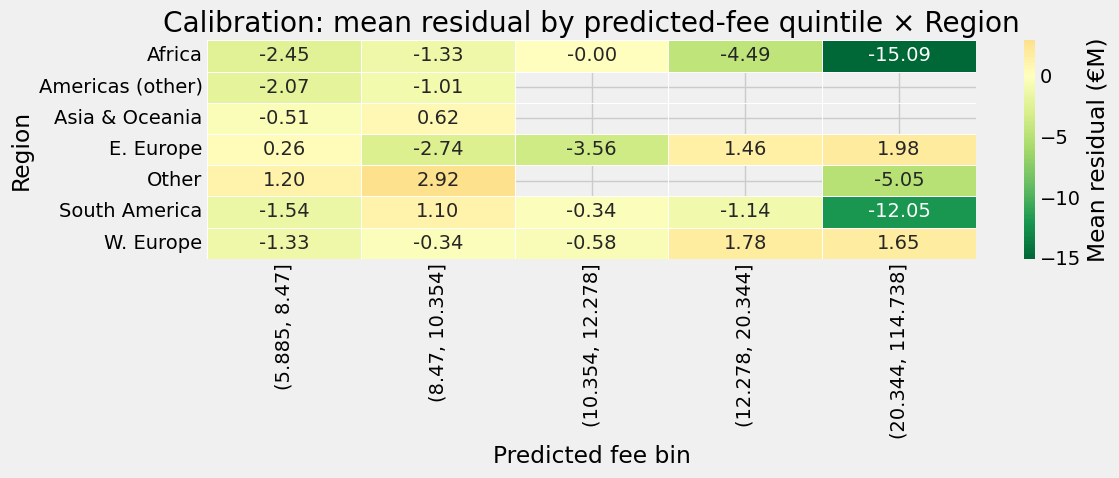

In [51]:
# ── Metric 3: Calibration — at similar predicted fees, do errors differ? ─────

eval_df['pred_bin'] = pd.qcut(
    eval_df['y_pred'], q=5, duplicates='drop',
)

print("=== Mean residual by predicted-fee quintile × Region ===")
cal_table = (
    eval_df.groupby(['pred_bin', 'Region'])['residual']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'mean_residual', 'count': 'n'})
    .round(3)
)
display(cal_table)

# ── Heatmap ──────────────────────────────────────────────────────────────────
cal_pivot = (
    eval_df.groupby(['pred_bin', 'Region'])['residual']
    .mean()
    .unstack(fill_value=np.nan)
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    cal_pivot.T,
    annot=True, fmt='.2f', center=0,
    cmap='RdYlGn_r', linewidths=0.5,
    cbar_kws={'label': 'Mean residual (€M)'},
    ax=ax,
)
ax.set_title('Calibration: mean residual by predicted-fee quintile × Region')
ax.set_xlabel('Predicted fee bin')
ax.set_ylabel('Region')
plt.tight_layout()
plt.show()

## Fairness findings

The RF model scores ~80% accuracy overall, but that single number hides an important pattern: the model does not err equally across groups.

### Who gets underpredicted?

The model consistently predicts lower fees than what was actually paid for players from Africa (−€3.71M on average), South America (−€3.36M), and Brazil specifically (−€5.82M). Western European players, by contrast, sit close to zero (+€0.29M). In plain terms, the model undervalues non-European transfers.

### Who gets the noisiest predictions?

The same groups that are underpredicted also get larger errors overall. Brazilian players have an MAE of €7.28M vs €4.32M for Western Europeans. African and South American players fall in between. So the model is not just biased in one direction — it is also less reliable for these groups.

### Does this hold at similar predicted fees?

Yes. The calibration heatmap shows that even when the model predicts a similar fee for two players, African and South American players still tend to have higher actual fees than predicted, while Western Europeans do not.

### Possible explanations

- FIFA ratings are the main ability proxy in the model. If those ratings undervalue non-European players, the model inherits that.
- League features were dropped before training. League carries geographic and market-structure information that could help the model distinguish these groups more fairly.
- Small samples: only 220 test transfers, 20 Brazilian, 23 African. The direction is clear but the exact numbers should be taken with caution.

### What could be improved

1. Add league-tier or region indicators back into the feature set.
2. Check whether the FIFA ratings themselves are biased by nationality.
3. Make group-level error reporting a standard step, not an afterthought.
4. Use cross-validated predictions for larger per-group sample sizes.

# Conclusion

Thank you all for bearing with me, and I hope you enjoyed this dive into Football Transfer Analysis and had as much fun as I had. Please give me comments for improvement and let me know if you liked what I did. Definitely, there is room for improvement in the models and the data analysis, so I'll come back from time to time and try to improve on this model. See you soon :)

And for the friends who I shared this journey with, thanks so much for viewing my creation. It means a lot and I really appreciate y'all. <3